In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pickle
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import OrderedDict
import einops
import torch
import torchinfo
import h5py
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import warnings

sys.path.insert(0, '/home/eo821/Documents/EchoStateNetwork/')
from esn.esn import ESN
from esn.utils import errors, scalers
sys.path.append('../')
from plotting.cae import plot_decoded_comparison
from plotting.esn import plot_esn_predictions
from src.neuralnetwork.preprocessing import normalize_data, train_valid_test_split, generate_esn_noise_data
from src.neuralnetwork.autoencoder.cae_ks_l66 import CAE
from src.utils.data_io import load_json_config, load_npy, load_pickle_dict
from src.utils.io_wrappers import wrap_decode_numpy, wrap_forward_numpy, wrap_encode_numpy
from src.data_assimilation.enkf import EnKF
warnings.filterwarnings("ignore", category=DeprecationWarning)
device = torch.device("cpu")  # if torch.cuda.is_available() else "cpu")
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif')

# Figures colors
color_true = 'gray'
color_unbias = '#000080ff'
color_bias = '#20b2aae5'
color_obs = 'r'
color_b = 'indigo'
colors_alpha = ['green', 'sandybrown', [0.7, 0.7, 0.87],
                'blue', 'red', 'gold', 'deepskyblue']

y_unbias_props = dict(marker='none', linestyle='--',
                      dashes=(10, 1), lw=.5, color=color_unbias)
esn_ens_props = dict(marker='none', linestyle='-',
                     lw=.2, color=color_bias, alpha=.9)
washout_ens_props = dict(marker='none', linestyle='-',
                         lw=.2, color="k", alpha=.7)
washout_ens_props = dict(marker='none', linestyle='-',
                         lw=.2, color="k", alpha=.9)

In [52]:
# ----------------------------
# Paths & Config Loading
# ----------------------------
modelpath = Path("../weights/ks_l20pi/dauntless-sweep-1")
esnpath = modelpath / "esn" / "10000"

ks_data = load_json_config(modelpath / "ks.json")
config = load_json_config(modelpath / "wandb_config.json")
esn_dict = load_pickle_dict(esnpath / "best_dict.pkl")
print(ks_data)
print(esn_dict)
# ----------------------------
# Load & Preprocess Data
# ----------------------------
data_path = Path("/storage0/eo821/KS/KS_128_dx62_99000_stand_3.58_deltat_0.25_M_64_trans.csv")
# Load full dataset
data = np.genfromtxt(data_path, delimiter=",", dtype=np.float64)
# Extract spatio-temporal data (skip transient)
U = data[1:, ks_data['N_trans']:]  # shape: (space, time)
sysdim = U.shape[0]
# Rearrange to (time, channels, space)
U = einops.rearrange(U, 'x time -> time 1 x')
# Extract time array
time_array = data[0]
# Normalize
U_normalized, maxnorm = normalize_data(U, normtype=ks_data['normtype'])
# Lyapunov time scaling
time_array_lyap = time_array / ks_data['t_lyap']
N_lyap = int(1 / ks_data['t_lyap'] / ks_data['dt'])
# Split into train, validation, test
U_train_series, U_valid_series, U_test_series = train_valid_test_split(U_normalized, ks_data)

# ----------------------------
# Model Loading
# ----------------------------
cae_model = CAE(config['latent_size']).to(device)
torchinfo.summary(cae_model, input_size=(1, 1, ks_data["Nx"]))
# Load pretrained weights
cae_model.load_state_dict(torch.load(modelpath / 'best_model.pth', map_location=device))
cae_model.to(device)
wrap_forward_numpy(cae_model, device)
wrap_encode_numpy(cae_model, device)
wrap_decode_numpy(cae_model, device)
# ----------------------------
# Encoding Data
# ----------------------------
U_encoded, U_decoded = cae_model(U_normalized)

{'upsample': 1, 'L': 67, 'N_data': 100000, 'N_trans': 1000, 'dt': 0.25, 'Nx': 128, 'Nu': 1, 'train_ratio': 0.5, 'valid_ratio': 0.1, 'b_size': 128, 'normtype': 'max', 't_lyap': 0.08}
{'reservoir_size': 10000, 'dimension': 24, 'reservoir_connectivity': 10, 'input_bias': array([1]), 'output_bias': array([1]), 'reservoir_weights_mode': 'erdos_renyi1', 'input_normalization': [array([-0.02025265,  0.01439961,  0.01297114,  0.01548875, -0.01127492,
       -0.03855802, -0.01731199, -0.0031711 ,  0.00166765,  0.02641685,
       -0.01411585,  0.00059135, -0.00298552,  0.01881336, -0.02819976,
        0.0646842 ,  0.00668405, -0.01583485,  0.00734384, -0.04423165,
        0.01386078, -0.00682314, -0.01313387,  0.00210296]), array([0.52056384, 0.50828821, 0.55006361, 0.49101659, 0.5746316 ,
       0.53197999, 0.54016614, 0.5681395 , 0.49504697, 0.48802266,
       0.51666316, 0.5304976 , 0.48416032, 0.53360493, 0.50640764,
       0.51969442, 0.57376187, 0.4897536 , 0.59622993, 0.54940182,
       0.

In [60]:
U_esn = generate_esn_noise_data(U_encoded, 1, sigma_n=1e-3)
u_encoded_train, u_encoded_valid, u_encoded_test = train_valid_test_split(U_esn, ks_data)
# Extract the shape of the original data
total_samples,latentdim = u_encoded_train.shape
N_washout = esn_dict["N_washout"]
# Split the data into different datasets
U_washout = u_encoded_train[:N_washout, ...]
U_train_input = u_encoded_train[N_washout:N_washout+esn_dict["train_size"]-1, ...]
U_train_label = u_encoded_train[N_washout + 1:N_washout+esn_dict["train_size"], ...]
U_val_input = u_encoded_valid[:esn_dict["val_size"]-1, ...]
U_val_label = u_encoded_valid[1:esn_dict["val_size"], ...]
U_test_washout = u_encoded_test[:N_washout, ...]
U_test = u_encoded_test[N_washout:, ...]
    
# Print shapes of datasets
print(f"Training data shape: {U_train_input.shape, U_train_label.shape}")
print(f"U_val shape: {U_val_input.shape, U_val_label.shape}")
print(f"U_test shape: {U_test.shape}")

Training data shape: ((49798, 24), (49798, 24))
U_val shape: ((9798, 24), (9798, 24))
U_test shape: (37900, 24)


In [61]:
i=0
my_ESN = ESN(reservoir_size=esn_dict["reservoir_size"],
               dimension=esn_dict["dimension"],
                reservoir_connectivity=esn_dict["reservoir_connectivity"],
                spectral_radius=esn_dict['spectral_radius'][i],
                input_scaling=esn_dict['input_scaling'][i],
                tikhonov=esn_dict['tikhonov'][i],
                input_bias=esn_dict["input_bias"],
                output_bias=np.array([0]),
                reservoir_weights_mode=esn_dict['reservoir_weights_mode'],
                input_normalization=esn_dict['input_normalization'],
                input_weights_mode=esn_dict['input_weights_mode'],
                #   leak_factor =min_dict['leak_factor'][i],
                input_seeds=esn_dict["input_seeds"],
                reservoir_seeds=esn_dict["reservoir_seeds"], verbose=False)
my_ESN.train(U_washout, U_train_input, U_train_label)

Training RMSE: 0.056963
Validation RMSE: 0.114459
Test RMSE: 0.088308


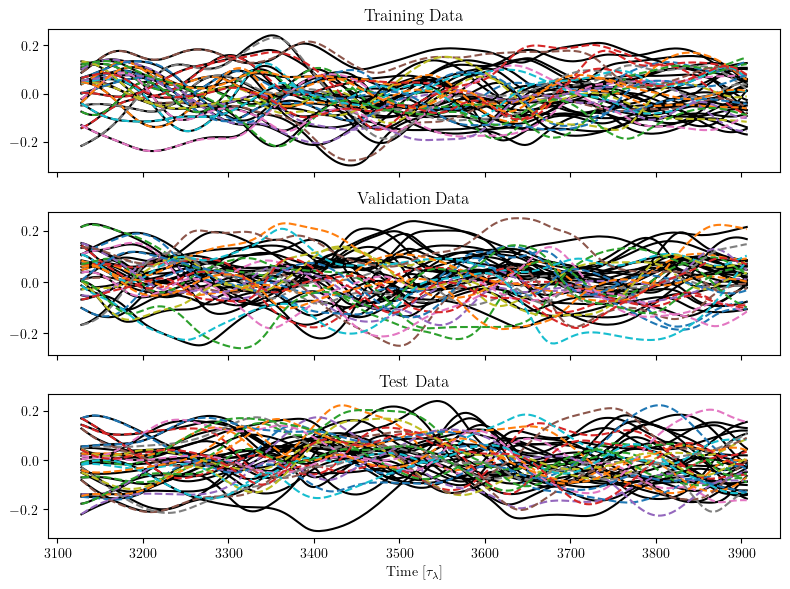

In [62]:

# Parameters
N_plot = 5*N_lyap
N_start = 1000

# Datasets for plotting
datasets = [
    (U_train_input, "Training"),
    (U_val_input, "Validation"),
    (U_test, "Test")
]

# Call the plotting function
fig, axes = plot_esn_predictions(
    my_ESN=my_ESN,
    datasets=datasets,
    time_array_lyap=time_array_lyap,
    N_start=N_start,
    N_washout=N_washout,
    N_plot=N_plot,
    latentdim=latentdim,
    errors=errors
)

# Save or show
# plt.show()
# fig.savefig("ks/L20pi_latent_prediction.png", dpi=100)

In [63]:
N_start = 200 
reservoir, prediction = my_ESN.closed_loop_with_washout(u_encoded_test[N_start:N_start+N_washout, :latentdim], 10000)# u_encoded_test.shape[0]-(N_start+N_washout))
U_prediction_decoded = cae_model.decode(prediction)
test_snapshot = cae_model.decode(u_encoded_test[N_start+N_washout:, :latentdim])

/home/eo821/Documents/DA-CAE-ESN/tutorial/../src/plotting.py:114: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes.set_yticklabels([f'{int(tick)}' for tick in axes.get_yticks()], fontsize=fs)


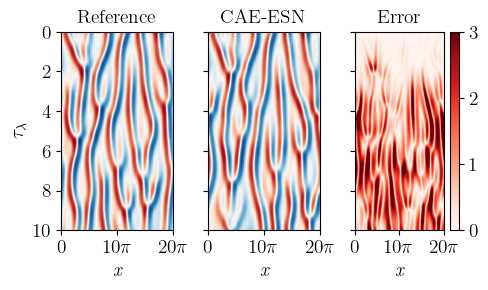

In [64]:
fig, axs = plot_decoded_comparison(
    test_snapshot=test_snapshot,
    U_prediction_decoded=U_prediction_decoded,
    maxnorm=3.58,
    N_plot=N_plot,
    N_lyap=N_lyap
)


In [65]:
latentdim=24

In [ ]:

# Function to add noise to observations

def add_noise(data, std_scale, shape):
    return data + np.random.normal(loc=0, scale=std_scale, size=shape)


def reservoir_with_bias(reservoir, bias_value):
    bias_column = np.ones((reservoir.shape[0], 1)) * bias_value
    return np.hstack((reservoir, bias_column))
    

def estimate_covariance(scale):
    return scale**2

# Decoder measurements 


In [293]:
kalman_params = {
    "N_as": 10,
    "N_ensemble": 50, 
    "N_steps": 50, 
    "sigma_washout": 0.05,
    "sigma_obs": 0.1, 
    "magnitude": "std",
    "randomseed": 0,
    "obs_sampling": 4, 
    "latentdim": latentdim
}


In [ ]:
forecasthorizon = kalman_params["N_as"]*kalman_params["N_steps"]+100
N_steps = N_lyap
 # Set seed for reproducibility
np.random.seed(5)
# Kalman Parameters
N_start=500
# N_steps = 100 #int(np.mean((locations[1:]-locations[:-1])))#s locations[-1]//N_as
washout_snapshots = U_test_series[N_start:N_start + N_washout]
washout_encoded = cae_model.encode(washout_snapshots)
truth = U_test[N_start + N_washout: N_start + N_washout+forecasthorizon, :]
# true_vorticity = U_test_series[N_start + N_washout: N_start + N_washout+N_as*N_steps*2, :]
true_encoded, true_decoded = cae_model(U_test_series[N_start + N_washout: N_start + N_washout+forecasthorizon, :])
true_vorticity = true_decoded[:, 0, :]
sigma_obs = 0.05 
washout_noise_ensemble = np.array([U_train_input[randint:randint+N_washout] for randint in np.random.randint(0, U_train_input.shape[0]-2*N_washout, kalman_params["N_ensemble"])])
sigma_obs=0.1
scale = sigma_obs * np.std(U_test_series[:, 0, selected_columns], axis=0)
# for obs_sampling in range(, 11):
obs_sampling=4
dim_obs_sampling = 128 // obs_sampling
selected_columns = np.arange(-dim_obs_sampling * obs_sampling, 0, step=obs_sampling)
# selected_columns = np.arange(-dim_obs_sampling * obs_sampling, 0)[:dim_obs_sampling]
M = np.zeros(shape=(dim_obs_sampling, esn_dict["reservoir_size"] + 128))
M[-dim_obs_sampling:, selected_columns] = np.eye(dim_obs_sampling)

Cdd = (estimate_covariance(scale) *np.eye(dim_obs_sampling)) #[selected_columns, :][:, selected_columns]

reservoir_size = esn_dict["reservoir_size"]
obs_ensemble = np.zeros((kalman_params["N_ensemble"], kalman_params["N_steps"], reservoir_size ))
obs_ensemble_step = np.zeros((kalman_params["N_ensemble"], kalman_params["N_steps"], reservoir_size ))
predictions = np.zeros((kalman_params["N_ensemble"], kalman_params["N_steps"], latentdim))
obs_ensemble = np.zeros((kalman_params["N_ensemble"], 1, reservoir_size ))
predictions_at = np.zeros((kalman_params["N_ensemble"], 1, latentdim))
measurements = truth[0:1]
locations = 0


obs_ensemble_step, predictions = run_esn_ensemble(my_ESN, washout_noise_ensemble, kalman_params, esn_dict["reservoir_size"], washout=True)


for j in range(kalman_params["N_as"]):
    
    obs_ensemble = np.append(obs_ensemble, obs_ensemble_step[:, :kalman_params["N_steps"]], axis=1)
    predictions_at = np.append(predictions_at, predictions[:, :kalman_params["N_steps"]], axis=1)
    sample_loc =  obs_ensemble.shape[1] - 1
    measurements = np.append(measurements, truth[sample_loc:sample_loc+1], axis=0)
    locations = np.append(locations, sample_loc)
    augmented_state = np.append(obs_ensemble[:, -1, :esn_dict["reservoir_size"]].T, cae_model.decode(predictions[:, -1])[:,0].T, axis=0)
    measurement = true_vorticity[sample_loc, selected_columns] 
    measurement_vorticity = ( measurement + np.random.normal(loc=0, scale=scale, size=(kalman_params["N_ensemble"], measurement.shape[0]))).T
    Aa = EnKF(Af=augmented_state, d=measurement_vorticity, Cdd=Cdd, M=M)
    obs_ensemble_step, predictions = run_esn_ensemble(my_ESN, Aa[: esn_dict["reservoir_size"]].T, kalman_params, esn_dict["reservoir_size"])

obs_ensemble = np.append(obs_ensemble[:, 1:, :], obs_ensemble_step[:, :kalman_params["N_steps"]], axis=1)
predictions_at = np.append(predictions_at[:, 1:, :], predictions[:, :kalman_params["N_steps"]], axis=1)
measurements = measurements[1:]
locations = locations[1:] + N_washout


In [ ]:
# Precompute constants
reservoir_size = esn_dict["reservoir_size"]
latentdim = kalman_params["latentdim"]
N_ensemble = kalman_params["N_ensemble"]

# Precompute selected columns
obs_sampling = 4
dim_obs_sampling = 128 // obs_sampling
selected_columns = np.arange(-dim_obs_sampling * obs_sampling, 0, step=obs_sampling)

# Preallocate or use lists
obs_ensemble_list = []
predictions_list = []
measurements_list = []
locations_list = []

# Initial washout
washout_noise_ensemble = np.array([
    U_train_input[randint:randint+N_washout] 
    for randint in np.random.randint(0, U_train_input.shape[0]-2*N_washout, N_ensemble)
])

obs_ensemble_step, predictions = run_esn_ensemble(
    my_ESN, washout_noise_ensemble, kalman_params, reservoir_size, washout=True
)

for j in range(kalman_params["N_as"]):
    obs_ensemble_list.append(obs_ensemble_step[:, :kalman_params["N_steps"]])
    predictions_list.append(predictions[:, :kalman_params["N_steps"]])

    sample_loc = sum([x.shape[1] for x in obs_ensemble_list]) - 1
    measurements_list.append(truth[sample_loc:sample_loc+1])
    locations_list.append(sample_loc)

    augmented_state = np.vstack([
        obs_ensemble_step[:, -1, :reservoir_size].T,
        cae_model.decode(predictions[:, -1])[:, 0].T
    ])

    measurement_vorticity = (true_vorticity[sample_loc, selected_columns] +
                             np.random.normal(0, scale, size=(N_ensemble, dim_obs_sampling))).T

    Aa = EnKF(Af=augmented_state, d=measurement_vorticity, Cdd=Cdd, M=M)
    obs_ensemble_step, predictions = run_esn_ensemble(
        my_ESN, Aa[:reservoir_size].T, kalman_params, reservoir_size
    )

# Convert lists to arrays at the end
obs_ensemble = np.concatenate(obs_ensemble_list, axis=1)
predictions_at = np.concatenate(predictions_list, axis=1)
measurements = np.concatenate(measurements_list, axis=0)
locations = np.array(locations_list) + N_washout


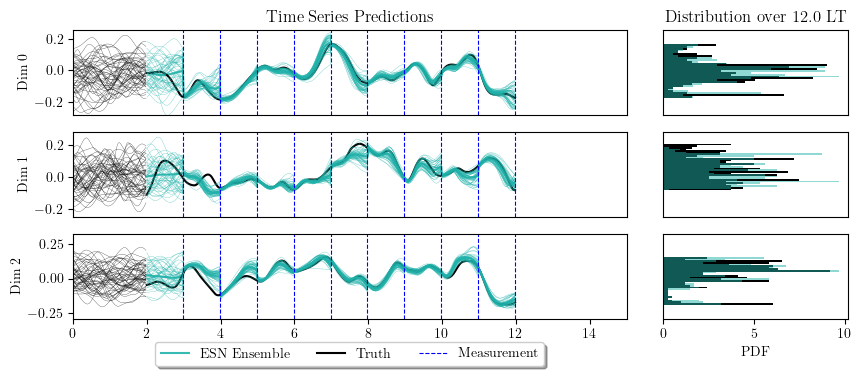

In [303]:
N_dims = 3
dt = 1 / N_lyap

# Create figure with GridSpec
fig = plt.figure(figsize=(10, 1.25 * N_dims))  
gs = gridspec.GridSpec(N_dims, 2, width_ratios=[3, 1], wspace=0.1)

axs, axs_hist = [], []

# Compute time arrays
time_prediction = np.arange(N_washout, obs_ensemble.shape[1] + N_washout) * dt
time_washout = np.arange(N_washout) * dt

# Compute predictions
predictions = obs_ensemble @ my_ESN.W_out[:esn_dict["reservoir_size"]]

for dim in range(N_dims):
    # Create subplots
    ax, ax_hist = fig.add_subplot(gs[dim, 0]), fig.add_subplot(gs[dim, 1])
    axs.append(ax), axs_hist.append(ax_hist)
    
    # Plot time series
    ax.plot(time_prediction, np.mean(predictions[:, :, dim], axis=0), color=color_bias, label="ESN Ensemble")
    ax.plot(time_prediction, truth[:len(time_prediction), dim], "k", label="Truth")
    
    for mi in range(obs_ensemble.shape[0]):
        ax.plot(time_washout, washout_noise_ensemble[mi, :, dim], **washout_ens_props)
        ax.plot(time_prediction, predictions[mi, :, dim], **esn_ens_props)

    for loc in locations:
        ax.axvline(x=loc / N_lyap, color="b", linestyle="--", linewidth=0.8,
                   label="Measurement" if loc == locations[0] else None)
    
    ax.set_ylim(np.min(U_test[:, dim]), np.max(U_test[:, dim]))
    ax.set_xlim(0, 15)
    ax.set_ylabel(f"Dim {dim}")

    # Histogram
    hist_data = truth[N_washout+N_steps:len(time_prediction), dim]
    bins = np.linspace(np.min(hist_data), np.max(hist_data), 30)
    ax_hist.hist(hist_data, bins=bins, density=True, orientation='horizontal', alpha=1.0, color='k')
    ax_hist.hist(np.mean(predictions[:, N_washout+N_steps:, dim], axis=0), bins=bins,
                 density=True, orientation='horizontal', alpha=0.5, color=color_bias)
    ax_hist.set_yticks([])
    ax_hist.set_ylim(np.min(U_test[:, dim]), np.max(U_test[:, dim]))
    
    if dim == 0:
        ax.set_title("Time Series Predictions")
        ax_hist.set_title(f"Distribution over {np.round(time_prediction[-1])} LT")
    if dim != N_dims - 1:
        ax.set_xticks([])
        ax_hist.set_xticks([])

ax_hist.set_xlabel("PDF", fontsize=10)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=5)
plt.show()


In [176]:
selected_columns

array([-128, -124, -120, -116, -112, -108, -104, -100,  -96,  -92,  -88,
        -84,  -80,  -76,  -72,  -68,  -64,  -60,  -56,  -52,  -48,  -44,
        -40,  -36,  -32,  -28,  -24,  -20,  -16,  -12,   -8,   -4])

Mean pointwise error: 0.13366259634494781


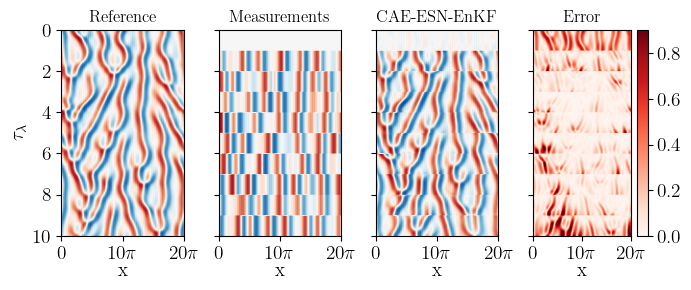

In [78]:
reservoir, reservoir_prediction = my_ESN.closed_loop_with_washout(washout_encoded, obs_ensemble.shape[1] + N_washout)
cmap = 'RdBu_r'
cmap_error = 'Reds'
fs = 14
# Calculate domain length
domain_length = 20 * np.pi
dt=0.25
N_plot = 10*N_lyap#60*N_lyap#len(time_prediction)
# Create subplots
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(7, 3), sharey=True)  # Changed ncols to 1
mean_prediction = np.mean(predictions, axis=0)
snapshot_decoded = cae_model.decode(mean_prediction)*maxnorm
snapshot = cae_model.decode(truth[:len(time_prediction), :])*maxnorm


# Extract data
data1 = snapshot[:N_plot, 0, :] 
# Create an empty measurements data array with the same shape as data1
measurements_data = np.zeros(shape= data1.shape)

# Loop over the rows of data1 and assign the measurements to measurements_data
for i in range(N_steps, data1.shape[0], N_steps):  # Loop over every 50th row
    measurements_data[i:i+N_steps, selected_columns] = data1[i, selected_columns] 
data2 = snapshot_decoded[:N_plot, 0, :] 
data3 = data1 - data2
# Calculate global vmin and vmax
vmin = -0.9*maxnorm# min(data1.min(), data2.min(), data3.min())
vmax = 0.9*maxnorm #max(data1.max(), data2.max(), data3.max())

lyapunov_time = 0.08 * np.arange(0, 10000, 0.25)
# Adjust subplot spacing
plt.subplots_adjust(wspace=-0.05)  #
# Plot data
for i, data in enumerate([data1,measurements_data, data2, data3]):
    axes = axs[i]
    if i==3:
        im = axes.imshow(np.abs(data), aspect='auto', cmap=cmap_error, vmin=0, vmax=vmax,
                     extent=[0, 2 * 10 * np.pi, int(lyapunov_time[N_plot]), lyapunov_time[0]])
    else:
        im = axes.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                        extent=[0, 2 * 10 * np.pi, int(lyapunov_time[N_plot]), lyapunov_time[0]])


    axes.set_xlabel('x', fontsize=fs, rotation=0, labelpad=0, y=0.46)
     # Set y-tick labels and font size
    axes.set_yticks(axes.get_yticks())  # Ensure yticks are set first
    axes.set_yticklabels([f'{int(tick)}' for tick in axes.get_yticks()], fontsize=fs)

    axes.yaxis.tick_left()
    axes.set_xticks(np.arange(0, 20 * np.pi + 0.01, step=(1 * 10 * np.pi)), ['0', r'$10\pi$', r'20$\pi$'],
                    fontsize=fs)
    for tick_label in axes.get_xticklabels():
        tick_label.set_ha('center')
        tick_label.set_x(-0.05)

cbar = fig.colorbar(im, ax=axes)
cbar.ax.tick_params(labelsize=fs)

axs[0].set_ylabel(r'$\tau_{\lambda}$', fontsize=fs)
axs[0].set_title("Reference")
axs[1].set_title("Measurements")
axs[2].set_title("CAE-ESN-EnKF")
axs[3].set_title("Error")
# Show or save plot
plt.tight_layout()
print(f"Mean pointwise error: {np.mean(np.abs(data3[:, :]))}")
# plt.savefig(f'../images/ks_cae_esn_enkf_comp.pdf', format='pdf', dpi=100, bbox_inches='tight')
# plt.savefig(f'../images/ks_cae_esn_enkf_comp.eps', format='eps', dpi=100, bbox_inches='tight')
# plt.savefig(f'../images/ks_cae_esn_enkf_comp.png', format='png', dpi=200, bbox_inches='tight')

In [ ]:
N_start=20000

/tmp/ipykernel_3693917/2192992740.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Mean pointwise error: 0.0009951217798516154


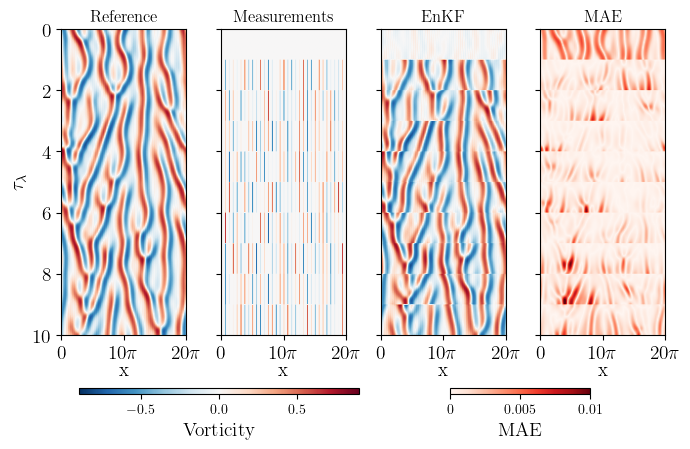

In [ ]:
# # Define constants
reservoir, reservoir_prediction = my_ESN.closed_loop_with_washout(
    washout_encoded, obs_ensemble.shape[1] + N_washout
)
cmap = 'RdBu_r'
cmap_error = 'Reds'
fs = 14
# Calculate domain length
domain_length = 20 * np.pi
N_plot = 10*N_lyap#60*N_lyap#len(time_prediction)
# Create subplots
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(7, 4), sharey=True)  # Changed ncols to 1
mean_prediction = np.mean(predictions, axis=0)
snapshot_decoded = cae_model.decode(mean_prediction)*maxnorm
snapshot = cae_model.decode(truth[:len(time_prediction), :]) *maxnorm


# Extract data
data1 = snapshot[:N_plot, 0, :] 
# Create an empty measurements data array with the same shape as data1
measurements_data = np.zeros(shape= data1.shape)

# Loop over the rows of data1 and assign the measurements to measurements_data
for i in range(N_steps, data1.shape[0], N_steps):  # Loop over every 50th row
    measurements_data[i:i+N_steps, ::obs_sampling] = data1[i, ::obs_sampling] 
data2 = snapshot_decoded[:N_plot, 0, :] 
data3 = np.abs(data1 - data2)/128
# Calculate global vmin and vmax
vmin = -0.9*maxnorm# min(data1.min(), data2.min(), data3.min())
vmax = 0.9*maxnorm #max(data1.max(), data2.max(), data3.max())
vmax_error=0.01
lyapunov_time = 0.08 * np.arange(0, 10000, (ks_data["dt"]*ks_data["upsample"]))
# Adjust subplot spacing
plt.subplots_adjust(wspace=-0.05)  #
# Plot data
for i, data in enumerate([data1,measurements_data, data2, data3]):
    axes = axs[i]
    if i==3:
        im_err = axes.imshow(data, aspect='auto', cmap=cmap_error, vmin=0, vmax=vmax_error,
                        extent=[0, 2 * 10 * np.pi, int(lyapunov_time[N_plot]), lyapunov_time[0]])

    else:    
        im_main = axes.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                        extent=[0, 2 * 10 * np.pi, int(lyapunov_time[N_plot]), lyapunov_time[0]])


    axes.set_xlabel('x', fontsize=fs, rotation=0, labelpad=0, y=0.46)
     # Set y-tick labels and font size
    axes.set_yticks(axes.get_yticks())  # Ensure yticks are set first
    axes.set_yticklabels([f'{int(tick)}' for tick in axes.get_yticks()], fontsize=fs)

    axes.yaxis.tick_left()
    axes.set_xticks(np.arange(0, 20 * np.pi + 0.01, step=(1 * 10 * np.pi)), ['0', r'$10\pi$', r'20$\pi$'],
                    fontsize=fs)
    for tick_label in axes.get_xticklabels():
        tick_label.set_ha('center')
        tick_label.set_x(-0.05)
y_pos=0.0
cax_main = fig.add_axes([0.12, y_pos, 0.4, 0.015])  # [left, bottom, width, height]
cbar_main = fig.colorbar(im_main, cax=cax_main, orientation='horizontal')
cbar_main.set_label("Vorticity", fontsize=fs)

cax_err = fig.add_axes([0.65, y_pos, 0.2, 0.015])
# cbar_err = fig.colorbar(im_err, cax=cax_err, orientation='horizontal')
# log_ticks = np.log10([1e-4, 1e-3, 1e-2])

# Create colorbar for error with custom ticks and formatting
cbar_err = fig.colorbar(im_err, cax=cax_err, orientation='horizontal')#, format=LogFormatter(10))
cbar_err.set_ticks([0,  0.005, 0.01])
cbar_err.ax.set_xticklabels([ 0, 0.005, 0.01])
# cbar_err.set_label(r"Error ($\log_{10}$ scale)", fontsize=fs)

cbar_err.set_label("MAE", fontsize=fs)


axs[0].set_ylabel(r'$\tau_{\lambda}$', fontsize=fs)
axs[0].set_title("Reference")
axs[1].set_title("Measurements")
axs[2].set_title("EnKF")
axs[3].set_title("MAE")
# Show or save plot
plt.tight_layout()
print(f"Mean pointwise error: {np.mean(np.abs(data3[:, :]))}")
# plt.savefig(f'../images/ks/v2/ks_cae_esn_enkf_comp.pdf', format='pdf', dpi=100, bbox_inches='tight')
# plt.savefig(f'../images/ks/v2/ks_cae_esn_enkf_comp.eps', format='eps', dpi=100, bbox_inches='tight')
# plt.savefig(f'../images/ks/v2/ks_cae_esn_enkf_comp.png', format='png', dpi=200, bbox_inches='tight')

/tmp/ipykernel_3588414/3131444574.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Mean pointwise error: 0.34803393483161926


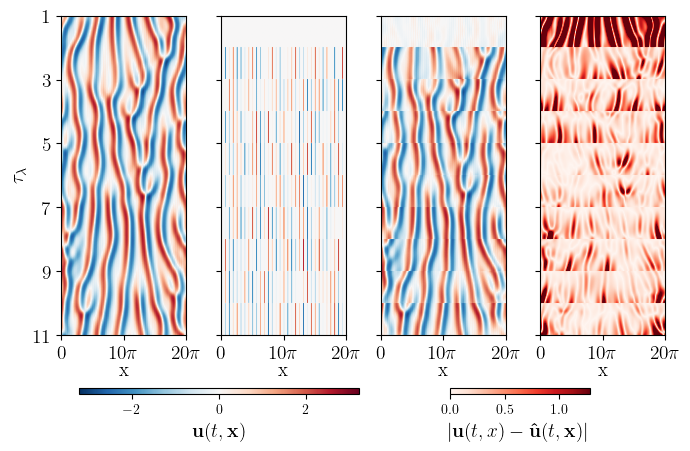

In [ ]:
# Define constants
reservoir, reservoir_prediction = my_ESN.closed_loop_with_washout(
    washout_encoded, obs_ensemble.shape[1] + N_washout
)
cmap = 'RdBu_r'
cmap_error = 'Reds'
fs = 14
# Calculate domain length
domain_length = 20 * np.pi
N_plot = 10*N_lyap#60*N_lyap#len(time_prediction)
# Create subplots
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(7, 4), sharey=True)  # Changed ncols to 1
mean_prediction = np.mean(predictions, axis=0)
snapshot_decoded = cae_model.decoder(torch.from_numpy(mean_prediction).float().to(device)).numpy(force=True) *maxnorm
snapshot = cae_model.decoder(torch.from_numpy(truth[:len(time_prediction), :]).float().to(device)).numpy(force=True)*maxnorm


# Extract data
data1 = snapshot[:N_plot, 0, :] 
# Create an empty measurements data array with the same shape as data1
measurements_data = np.zeros(shape= data1.shape)

# Loop over the rows of data1 and assign the measurements to measurements_data
for i in range(N_steps, data1.shape[0], N_steps):  # Loop over every 50th row
    measurements_data[i:i+N_steps, ::obs_sampling] = data1[i, ::obs_sampling] 
data2 = snapshot_decoded[:N_plot, 0, :] 
data3 = np.abs(data1 - data2)
# Calculate global vmin and vmax
vmin = -0.9*maxnorm# min(data1.min(), data2.min(), data3.min())
vmax = 0.9*maxnorm #max(data1.max(), data2.max(), data3.max())
vmax_error=0.01*128
lyapunov_time = 0.08 * np.arange(0, 10000, (ks_data["dt"]*ks_data["upsample"]))
# Adjust subplot spacing
plt.subplots_adjust(wspace=-0.05)  #
# Plot data
for i, data in enumerate([data1,measurements_data, data2, data3]):
    axes = axs[i]
    if i==3:
        im_err = axes.imshow(data, aspect='auto', cmap=cmap_error, vmin=0, vmax=vmax_error,
                        extent=[0, 2 * 10 * np.pi, int(lyapunov_time[N_plot]), lyapunov_time[0]])

    else:    
        im_main = axes.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                        extent=[0, 2 * 10 * np.pi, int(lyapunov_time[N_plot]), lyapunov_time[0]])


    axes.set_xlabel('x', fontsize=fs, rotation=0, labelpad=0, y=0.46)
     # Set y-tick labels and font size
    axes.set_yticks(axes.get_yticks())  # Ensure yticks are set first
    axes.set_yticklabels([f'{int(tick)+1}' for tick in axes.get_yticks()], fontsize=fs)

    axes.yaxis.tick_left()
    axes.set_xticks(np.arange(0, 20 * np.pi + 0.01, step=(1 * 10 * np.pi)), ['0', r'$10\pi$', r'20$\pi$'],
                    fontsize=fs)
    for tick_label in axes.get_xticklabels():
        tick_label.set_ha('center')
        tick_label.set_x(-0.05)
y_pos=0.0
cax_main = fig.add_axes([0.12, y_pos, 0.4, 0.015])  # [left, bottom, width, height]
cbar_main = fig.colorbar(im_main, cax=cax_main, orientation='horizontal')
cbar_main.set_label(r"$\mathbf{u}(t,\mathbf{x})$", fontsize=fs)

cax_err = fig.add_axes([0.65, y_pos, 0.2, 0.015])
# cbar_err = fig.colorbar(im_err, cax=cax_err, orientation='horizontal')
# log_ticks = np.log10([1e-4, 1e-3, 1e-2])

# Create colorbar for error with custom ticks and formatting
cbar_err = fig.colorbar(im_err, cax=cax_err, orientation='horizontal')#, format=LogFormatter(10))
# cbar_err.set_ticks([0,  0.005, 0.01])
# cbar_err.ax.set_xticklabels([ 0, 0.005, 0.01])
# cbar_err.set_label(r"Error ($\log_{10}$ scale)", fontsize=fs)

cbar_err.set_label(r"$|\mathbf{u}(t, x) - \mathbf{\hat{u}}(t, \mathbf{x})|$", fontsize=fs)


axs[0].set_ylabel(r'$\tau_{\lambda}$', fontsize=fs)
# axs[0].set_title("Reference")
# axs[1].set_title("Measurements")
# axs[2].set_title("EnKF")
# axs[3].set_title("MAE")
# Show or save plot
plt.tight_layout()
print(f"Mean pointwise error: {np.mean(np.abs(data3[:, :]))}")
plt.savefig(f'../images/ks/v2/ks_cae_esn_enkf_comp_editedtime.pdf', format='pdf', dpi=100, bbox_inches='tight')
plt.savefig(f'../images/ks/v2/ks_cae_esn_enkf_comp_editedtime.eps', format='eps', dpi=100, bbox_inches='tight')
plt.savefig(f'../images/ks/v2/ks_cae_esn_enkf_comp_editedtime.png', format='png', dpi=200, bbox_inches='tight')

/tmp/ipykernel_3588414/1592021261.py:38: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f'{int(tick)}' for tick in ax.get_yticks()], fontsize=fs)
/tmp/ipykernel_3588414/1592021261.py:49: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f'{int(tick)}' for tick in ax.get_yticks()], fontsize=fs)


Mean pointwise error: 1.5002994537353516


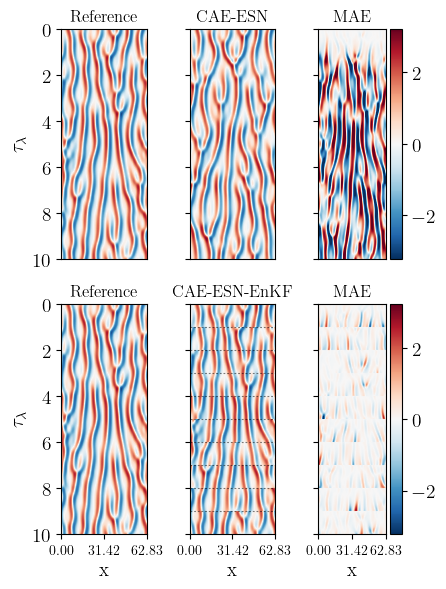

In [ ]:
# Decocde 
washout_snapshots = U_test_series[N_start + N_washout:N_start + 2 * N_washout]
washout_encoded = cae_model.encoder(torch.from_numpy(washout_snapshots).float().to(device)).numpy(force=True)
reservoir, reservoir_prediction = my_ESN.closed_loop_with_washout(washout_encoded, obs_ensemble.shape[1] + N_washout)
cae_esn_pred_decoded = cae_model.decoder(torch.from_numpy(reservoir_prediction).float().to(device)).numpy(force=True) * maxnorm

# Plot settings
cmap = 'RdBu_r'
fs = 14
domain_length = 20 * np.pi
N_plot = 10 * N_lyap

# Create subplots
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(4.5, 6), sharey=True)
mean_prediction = np.mean(predictions, axis=0)
snapshot_decoded = cae_model.decoder(torch.from_numpy(mean_prediction).float().to(device)).numpy(force=True) * maxnorm
snapshot = cae_model.decoder(torch.from_numpy(truth[:len(time_prediction), :]).float().to(device)).numpy(force=True) * maxnorm

# Extract data
data1 = snapshot[N_washout:N_washout + N_plot, 0, :]
data2 = cae_esn_pred_decoded[:N_plot, 0, :]
data3 = data1 - data2
data5 = snapshot_decoded[N_washout:N_washout + N_plot, 0, :]
data6 = data1 - data5

# Color limits
vmin, vmax = -0.9 * maxnorm, 0.9 * maxnorm
lyapunov_time = 0.08 * np.arange(0, 10000, (ks_data["dt"] * ks_data["upsample"]))

# Adjust subplot spacing
plt.subplots_adjust(wspace=-0.05)

# Plot data
for i, data in enumerate([data1, data2, data3]):
    ax = axs[0, i]
    im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                    extent=[0, 2 * 10 * np.pi, int(lyapunov_time[N_plot]), lyapunov_time[0]])
    ax.set_yticklabels([f'{int(tick)}' for tick in ax.get_yticks()], fontsize=fs)
    ax.set_xticks([])

cbar = fig.colorbar(im, ax=axs[0, -1])
cbar.ax.tick_params(labelsize=fs)

for i, data in enumerate([data1, data5, data6]):
    ax = axs[1, i]
    im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                    extent=[0, 2 * 10 * np.pi, int(lyapunov_time[N_plot]), lyapunov_time[0]])
    ax.set_xlabel('x', fontsize=fs)
    ax.set_yticklabels([f'{int(tick)}' for tick in ax.get_yticks()], fontsize=fs)
    ax.set_xticks(np.arange(0, 20 * np.pi + 0.01, step=(1 * 10 * np.pi)))

cbar = fig.colorbar(im, ax=axs[1, -1])
cbar.ax.tick_params(labelsize=fs)

for loc in [50, 100, 150, 200, 250, 300, 350, 400, 450]:
    axs[1, 1].axhline(y=loc / N_lyap, color="k", linestyle=(0, (1.6, 1.7)), linewidth=0.8, alpha=0.5)

# Set titles and labels
axs[0, 0].set_ylabel(r'$\tau_{\lambda}$', fontsize=fs)
axs[1, 0].set_ylabel(r'$\tau_{\lambda}$', fontsize=fs)
axs[0, 0].set_title("Reference")
axs[1, 0].set_title("Reference")
axs[0, 1].set_title("CAE-ESN")
axs[1, 1].set_title("CAE-ESN-EnKF")
axs[0, 2].set_title("MAE")
axs[1, 2].set_title("MAE")

# Final layout adjustments
plt.tight_layout()
print(f"Mean pointwise error: {np.mean(np.abs(data3[:, :]))}")
# plt.savefig(f'../images/ks_caeesn_vsenkf_comp.pdf', format='pdf', dpi=100, bbox_inches='tight')
# plt.savefig(f'../images/ks_caeesn_vs_enkf_comp.eps', format='eps', dpi=100, bbox_inches='tight')
# plt.savefig(f'../images/ks_caeesn_vs_enkf_comp.png', format='png', dpi=200, bbox_inches='tight')

In [ ]:
mpl.rc('text', usetex = True)
mpl.rc('font', family = 'serif')            

Mean pointwise error (CAE-ESN): 1.5003


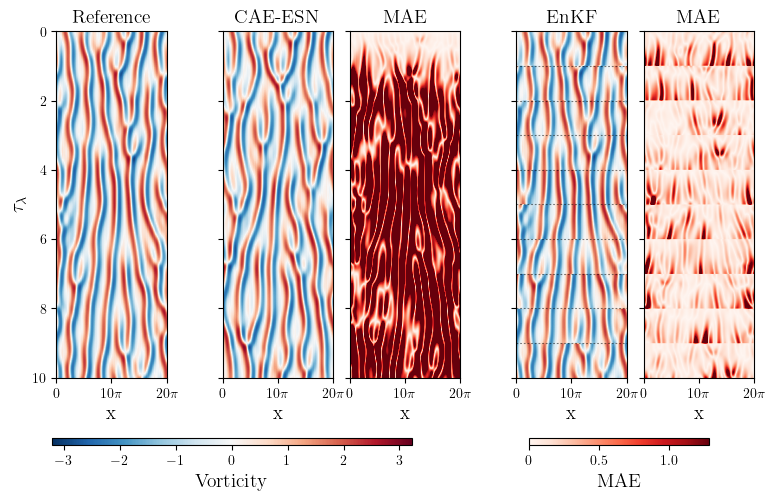

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
from matplotlib.ticker import FuncFormatter

# Define data
data1 = snapshot[N_washout:N_washout + N_plot, 0, :]         # Reference
data2 = cae_esn_pred_decoded[:N_plot, 0, :]                   # CAE-ESN
data3 = np.abs(data1 - data2)                    # CAE-ESN Error
data5 = snapshot_decoded[N_washout:N_washout + N_plot, 0, :]  # CAE-ESN-EnKF
data6 = np.abs(data1 - data5)                           # CAE-ESN-EnKF Error
from matplotlib.ticker import LogFormatter

# Prepare log-scaled error dat

# Plot settings
cmap_default = 'RdBu_r'
cmap_error = 'Reds'
fs = 14
vmin, vmax = -0.9 * maxnorm, 0.9 * maxnorm
vmin_err, vmax_err = 0, 0.01*128

lyapunov_time = 0.08 * np.arange(0, 10000, (ks_data["dt"] * ks_data["upsample"]))
extent = [0, 2 * 10 * np.pi, int(lyapunov_time[N_plot]), lyapunov_time[0]]

# Create figure and GridSpec layout
fig = plt.figure(figsize=(9, 4.5))
gs = GridSpec(1, 7, figure=fig, width_ratios=[1, 0.2, 1, 1, 0.2, 1, 1], wspace=0.2)

# Formatter for x-axis ticks as multiples of pi
def pi_formatter(x, pos):
    n = x / np.pi
    if np.isclose(n, 0):
        return "0"
    elif np.isclose(n, 1):
        return r"$\pi$"
    elif np.isclose(n % 1, 0):
        return fr"${int(n)}\pi$"
    else:
        return ""

# Dictionary with image data and titles
titles = ["Reference", "CAE-ESN", "MAE", "EnKF", "MAE"]
data_dict = {
    0: (data1, titles[0], cmap_default, vmin, vmax),
    2: (data2, titles[1], cmap_default, vmin, vmax),
    3: (data3, titles[2], cmap_error, vmin_err, vmax_err),
    5: (data5, titles[3], cmap_default, vmin, vmax),
    6: (data6, titles[4], cmap_error, vmin_err, vmax_err),
}

# Hold image handles for colorbars
im_main, im_err = None, None

# Add subplots
for idx in range(7):
    ax = fig.add_subplot(gs[0, idx])
    if idx in data_dict:
        data, title, cmap, vmin_val, vmax_val = data_dict[idx]
        im = ax.imshow(data, aspect='auto', cmap=cmap,
                       vmin=vmin_val, vmax=vmax_val, extent=extent)
        ax.set_title(title, fontsize=fs)
        xticks = np.arange(0, 21 * np.pi, 10 * np.pi)
        ax.set_xticks(xticks)
        ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))
        ax.set_xlabel("x", fontsize=fs)
        if idx == 0:
            ax.set_ylabel(r'$\tau_{\lambda}$', fontsize=fs)
        else:
            ax.set_yticklabels([])

        # Keep handles for colorbars
        if "MAE" in title:
            im_err = im
        else:
            im_main = im

        if idx == 5:
            for loc in [50, 100, 150, 200, 250, 300, 350, 400, 450]:
                ax.axhline(y=loc / N_lyap, color="k", linestyle=(0, (1.6, 1.7)), linewidth=0.8, alpha=0.5)
    else:
        ax.axis('off')
y_pos=-.04
# Add dual horizontal colorbars
cax_main = fig.add_axes([0.12, y_pos, 0.4, 0.015])  # [left, bottom, width, height]
cbar_main = fig.colorbar(im_main, cax=cax_main, orientation='horizontal')
cbar_main.set_label("Vorticity", fontsize=fs)

cax_err = fig.add_axes([0.65, y_pos, 0.2, 0.015])
# cbar_err = fig.colorbar(im_err, cax=cax_err, orientation='horizontal')
# log_ticks = np.log10([1e-4, 1e-3, 1e-2])

# Create colorbar for error with custom ticks and formatting
cbar_err = fig.colorbar(im_err, cax=cax_err, orientation='horizontal', format=LogFormatter(10))
cbar_err.set_ticks([0,  0.5, 1.0])
cbar_err.ax.set_xticklabels([ 0, 0.5, 1.0])
# cbar_err.set_label(r"Error ($\log_{10}$ scale)", fontsize=fs)

cbar_err.set_label("MAE", fontsize=fs)

# plt.tight_layout(rect=[0, 0.18, 0.93, 1])
print(f"Mean pointwise error (CAE-ESN): {np.mean(data3):.4f}")
# _comp.png', format='png', dpi=200, bbox_inches='tight')
plt.savefig(f'../images/ks/v2/ks_caeesn_vsenkf_comp.pdf', format='pdf', dpi=100, bbox_inches='tight')
plt.savefig(f'../images/ks/v2/ks_caeesn_vs_enkf_comp.eps', format='eps', dpi=100, bbox_inches='tight')
plt.savefig(f'../images/ks/v2/ks_caeesn_vs_enkf_comp.png', format='png', dpi=200, bbox_inches='tight')

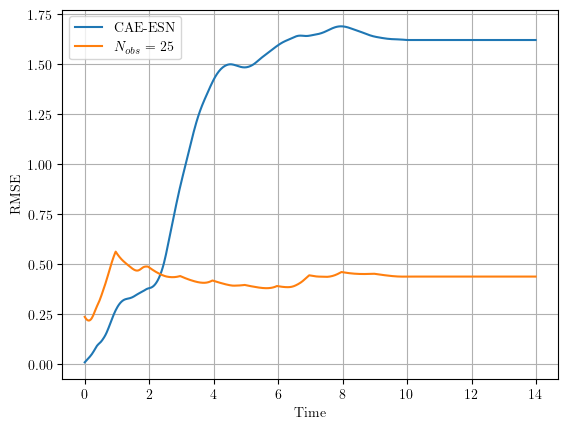

In [ ]:
def rmse(data1, data2):
    return np.sqrt(np.mean((data1 - data2) ** 2))

N_plot = 14*N_lyap

# Compute cumulative RMSE over time
rmse_time_caeesn = [rmse(data1[1:i, :], data2[1:i, :]) for i in range(2, N_plot+2)]
rmse_time_caeesnekf = [rmse(data1[1:i, :], data5[1:i, :]) for i in range(2, N_plot+2)]

# Plot the RMSE growth over time
plt.plot(lyapunov_time[:N_plot], rmse_time_caeesn, label="CAE-ESN")
plt.plot(lyapunov_time[:N_plot], rmse_time_caeesnekf, label="$N_{obs}=25$")
plt.xlabel("Time")
plt.ylabel("RMSE")
# plt.yscale("symlog")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def inflate_ensemble(A, rho):
    A_m = np.mean(A, -1, keepdims=True)
    return A_m + rho * (A - A_m)

In [ ]:
# Iterate over different sampling values (from 1 to 10)
for obs_sampling in [1, 2, 4, 5, 6, 8]:
    
   latentdim_sampling = 128 // obs_sampling
    print(dim_sampling)

128
64
32
25
21
16


In [ ]:
# Initialize dictionary to store predictions for each obs_sampling number
N_start=20000
predictions_all_sampling = {}
N_as= 15
N_ensemble=100
N_steps = N_lyap
 # Set seed for reproducibility
np.random.seed(111)
# Kalman Parameters
# N_steps = 100 #int(np.mean((locations[1:]-locations[:-1])))#s locations[-1]//N_as
washout_snapshots = U_test_series[N_start:N_start + N_washout]
washout_encoded = cae_model.encoder(torch.from_numpy(washout_snapshots).float().to(device)).numpy(force=True)
truth = U_test[N_start + N_washout: N_start + N_washout+N_as*N_steps*2, :]
# true_vorticity = U_test_series[N_start + N_washout: N_start + N_washout+N_as*N_steps*2, :]
true_encoded, true_vorticity = cae_model(torch.from_numpy(U_test_series[N_start + N_washout: N_start + N_washout+N_as*N_steps*2, :]).float().to(device))
true_encoded = true_encoded.numpy(force=True)
true_vorticity = true_vorticity.numpy(force=True)
sigma_obs = 0.05
washout_noise_ensemble = add_noise(washout_encoded, sigma_obs * np.std(U_encoded, axis=0), (N_ensemble, N_washout, latentdim))

washout_noise_ensemble = np.array([U_train_input[randint:randint+N_washout] for randint in np.random.randint(0, U_train_input.shape[0]-2*N_washout, N_ensemble)])
sigma_obs=0.2
vorticity_obs_ensemble = true_vorticity[:, 0, :] + np.random.normal(loc=0, scale=sigma_obs * np.std(U_test_series, axis=0), size=(N_ensemble, true_vorticity.shape[0], true_vorticity.shape[-1]))


# Iterate over different obs_sampling values (from 1 to 10)
for obs_sampling in [1, 2, 4, 5, 6, 8]:
    
   latentdim_sampling = 128 // obs_sampling
    selected_columns = np.arange(-dim_sampling * obs_sampling, 0, step=sampling)
    M = np.zeros(shape=(dim_sampling, esn_dict["reservoir_size"] + 128))
    M[-dim_sampling:, selected_columns] = np.eye(dim_sampling)

    Cdd = calculate_observation_error_covariance(vorticity_obs_ensemble[:, :, selected_columns])

    reservoir_size = esn_dict["reservoir_size"]
    obs_ensemble = np.zeros((N_ensemble, N_steps, reservoir_size ))
    obs_ensemble_step = np.zeros((N_ensemble, N_steps, reservoir_size ))
    predictions = np.zeros((N_ensemble, N_steps, latentdim))
    # bias = np.repeat((my_ESN.W_out[esn_dict["reservoir_size"]:] * my_ESN.b_out), N_as=N_ensemble, axis=0).T
    obs_ensemble = np.zeros((N_ensemble, 1, reservoir_size ))
    predictions_at = np.zeros((N_ensemble, 1, latentdim))
    measurements = truth[0:1]
    locations = 0


    for i in range(N_ensemble):
        reservoir, prediction = my_ESN.closed_loop_with_washout( washout_noise_ensemble[i], N_steps)
        obs_ensemble_step[i] = reservoir[1:] #reservoir_with_bias(reservoir[1:], my_ESN.b_out)
        predictions[i] = prediction[1:]


    for j in range(N_as):

        measurement_idx = N_steps
        obs_ensemble = np.append(obs_ensemble, obs_ensemble_step[:, :measurement_idx], axis=1)
        predictions_at = np.append(predictions_at, predictions[:, :measurement_idx], axis=1)

        print(measurement_idx, obs_ensemble.shape[1] - 1)
        sample_loc =  obs_ensemble.shape[1] - 1
        measurements = np.append(measurements, truth[sample_loc:sample_loc+1], axis=0)
        locations = np.append(locations, sample_loc)

        augmented_state = np.append(obs_ensemble[:, -1, :esn_dict["reservoir_size"]].T, cae_model.decoder(torch.from_numpy(predictions[:, -1, :]).float().to(device)).numpy(force=True).T[:, 0,:], axis=0)
        #  observations_ensemble_new[:, sample_loc, :].T  - bias
        measurement_vorticity = vorticity_obs_ensemble[:,sample_loc, :].T[selected_columns, :]
        Aa = EnKF(Af=augmented_state, d=measurement_vorticity, Cdd=Cdd, M=M)
        if obs_sampling==1:
            Aa = inflate_ensemble(Aa,1.1)
        elif obs_sampling==2:
            Aa = inflate_ensemble(Aa,1.05)
        for i in range(N_ensemble):
            reservoir, prediction = my_ESN.closed_loop(Aa[: esn_dict["reservoir_size"], i], N_steps)
            obs_ensemble_step[i] = reservoir[1:] #reservoir_with_bias(reservoir[1:], my_ESN.b_out) 
            predictions[i] = prediction[1:]

        # After all N_as, store the predictions for the current obs_sampling value
        predictions_all_sampling[sampling] = predictions_at  # Save predictions for this obs_sampling value

    # Print or analyze predictions if needed for each obs_sampling
    print(f"Predictions for obs_sampling={sampling} completed.")


50 50
50 100
50 150
50 200
50 250
50 300
50 350
50 400
50 450
50 500
50 550
50 600
50 650
50 700
50 750
Predictions for sampling=1 completed.
50 50
50 100
50 150
50 200
50 250
50 300
50 350
50 400
50 450
50 500
50 550
50 600
50 650
50 700
50 750
Predictions for sampling=2 completed.
50 50
50 100
50 150
50 200
50 250
50 300
50 350
50 400
50 450
50 500
50 550
50 600
50 650
50 700
50 750
Predictions for sampling=4 completed.
50 50
50 100
50 150
50 200
50 250
50 300
50 350
50 400
50 450
50 500
50 550
50 600
50 650
50 700
50 750
Predictions for sampling=5 completed.
50 50
50 100
50 150
50 200
50 250
50 300
50 350
50 400
50 450
50 500
50 550
50 600
50 650
50 700
50 750
Predictions for sampling=6 completed.
50 50
50 100
50 150
50 200
50 250
50 300
50 350
50 400
50 450
50 500
50 550
50 600
50 650
50 700
50 750
Predictions for sampling=8 completed.


In [ ]:
washout_snapshots_caeesn = U_test_series[N_start+N_washout:N_start + 2*N_washout]
washout_encoded_caeesn = cae_model.encoder(torch.from_numpy(washout_snapshots_caeesn).float().to(device)).numpy(force=True)
N_plot = 50*N_lyap
reservoir, reservoir_prediction = my_ESN.closed_loop_with_washout(washout_encoded_caeesn, N_plot + N_washout)
cae_esn_pred_decoded = cae_model.decoder(torch.from_numpy(reservoir_prediction).float().to(device)).numpy(force=True)*maxnorm
cmap = 'RdBu_r'
fs = 14
# Calculate domain length
domain_length = 20 * np.pi

# Create subplots# Changed ncols to 1
mean_prediction = np.mean(predictions, axis=0)
snapshot_decoded = cae_model.decoder(torch.from_numpy(mean_prediction).float().to(device)).numpy(force=True) *maxnorm
snapshot = cae_model.decoder(torch.from_numpy(truth[:len(time_prediction), :]).float().to(device)).numpy(force=True)*maxnorm

# Extract data
data1 = snapshot[N_washout:N_washout+N_plot, 0, :] 
data2 = cae_esn_pred_decoded[:N_plot, 0, :] 

In [ ]:
predictions_all_sampling[1].shape[1] /50

15.02

In [ ]:
# Initialize dictionary to store predictions for each sampling number
N_start=20000
N_as= 100
N_ensemble=100
N_steps = N_lyap
 # Set seed for reproducibility
np.random.seed(111)
# Kalman Parameters
# N_steps = 100 #int(np.mean((locations[1:]-locations[:-1])))#s locations[-1]//N_as
washout_snapshots = U_test_series[N_start:N_start + N_washout]
washout_encoded = cae_model.encoder(torch.from_numpy(washout_snapshots).float().to(device)).numpy(force=True)
truth = U_test[N_start + N_washout: N_start + N_washout+N_as*N_steps*2, :]
# true_vorticity = U_test_series[N_start + N_washout: N_start + N_washout+N_as*N_steps*2, :]
true_encoded, true_vorticity = cae_model(torch.from_numpy(U_test_series[N_start + N_washout: N_start + N_washout+N_as*N_steps*2, :]).float().to(device))
true_encoded = true_encoded.numpy(force=True)
true_vorticity = true_vorticity.numpy(force=True)

In [ ]:
washout_noise_ensemble.shape

(100, 100, 24)

/tmp/ipykernel_2972500/4137528892.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


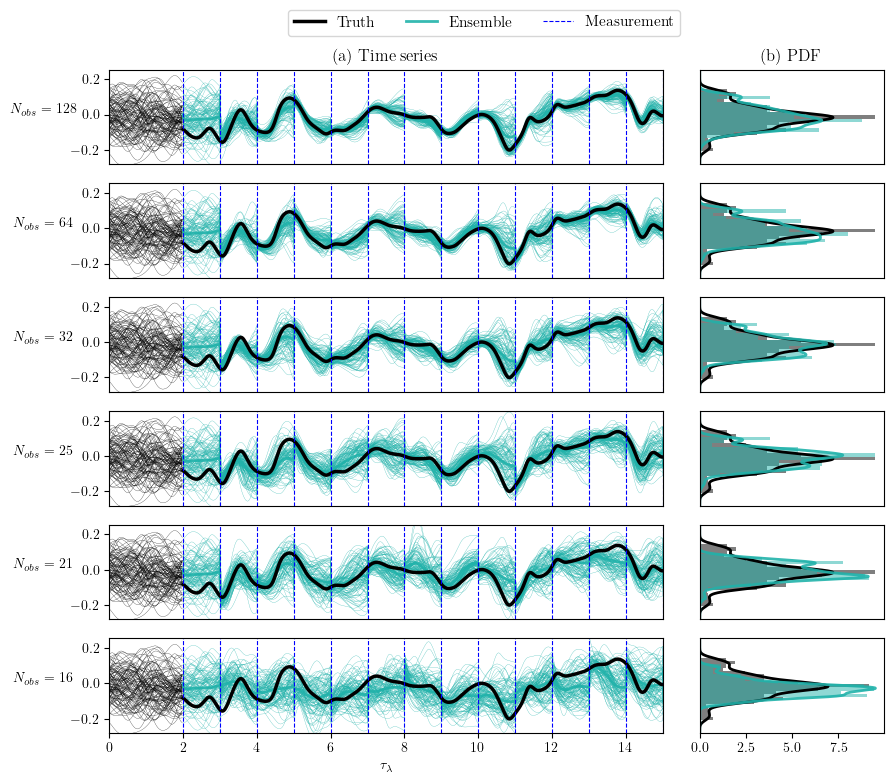

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.stats import gaussian_kde

# Set up figure and GridSpec layout
fig = plt.figure(figsize=(10, 1.4 * len(predictions_all_sampling)))
gs = gridspec.GridSpec(len(predictions_all_sampling), 2, width_ratios=[3, 1], wspace=0.1)

# Initialize axes
axs = []
axs_hist = []

# Time arrays
time_prediction = np.arange(N_washout,  predictions_all_sampling[1].shape[1] + N_washout) /N_lyap
time_washout = np.arange(0, N_washout) /N_lyap
truth = U_test[N_start+ N_washout: N_start + N_washout + len(time_prediction) + 200, :]
y_vals = np.linspace(np.min(truth), np.max(truth), 500)
# KDE histogram helper
def plot_hist_with_outline(ax, data, color, bins, alpha=0.3, lw=2):
    ax.hist(data, bins=bins, density=True, orientation='horizontal', alpha=alpha, color=color, edgecolor=None)
    kde = gaussian_kde(data)

    ax.plot(kde(y_vals), y_vals, color=color, linewidth=lw)

# Loop over each sampling
for idx, sampling in enumerate(predictions_all_sampling.keys()):
    ax = fig.add_subplot(gs[idx, 0])
    ax_hist = fig.add_subplot(gs[idx, 1])

    axs.append(ax)
    axs_hist.append(ax_hist)

    predictions = predictions_all_sampling[sampling]

    # Plot ensemble predictions
    for mi in range(obs_ensemble.shape[0]):
        ax.plot(time_washout, washout_noise_ensemble[mi, :, 0], **washout_ens_props)
        ax.plot(time_prediction, predictions[mi, :, 0], **esn_ens_props)

    # Plot mean prediction and truth
    ax.plot(time_prediction, np.mean(predictions[:, :, 0], axis=0), color=color_bias, linewidth=2, label="Ensemble Mean")
    ax.plot(time_prediction, truth[:len(time_prediction), 0], "k", linewidth=2.5, label="Truth")

    # Add measurement markers
    for loc in locations:
        ax.axvline(x=loc / N_lyap + 2, color="b", linestyle="--", linewidth=0.8, label="Measurement" if loc == locations[0] else None)

    # Format axes
    ax.set_ylim(np.min(U_test[:, 0]), np.max(U_test[:, 0]))
    ax.set_xlim(0, 15)
    ax.set_ylabel(f"$N_{{obs}}={128 // obs_sampling}$", rotation=0, labelpad=20)
    if idx != len(predictions_all_sampling) - 1:
        ax.set_xticks([])
        ax_hist.set_xticks([])

    # Plot smoothed histogram on right
    bins = np.linspace(np.min(U_test[:, 0]), np.max(U_test[:, 0]), 30)
    hist_truth = truth[N_washout + N_steps : len(time_prediction), 0]
    hist_pred = np.mean(predictions[:, N_washout + N_steps :, 0], axis=0)

    plot_hist_with_outline(ax_hist, hist_truth, "black", bins, alpha=0.5)
    plot_hist_with_outline(ax_hist, hist_pred, color_bias, bins, alpha=0.5)

    ax_hist.set_yticks([])
    ax_hist.set_ylim(np.min(U_test[:, 0]), np.max(U_test[:, 0]))

    # Add subplot labels to top row
    if idx == 0:
        ax.set_title("(a) Time series")
        ax_hist.set_title("(b) PDF")
ax.set_xlabel(r"$\tau_{\lambda}$")
# Add legend across top
lines = [
    plt.Line2D([0], [0], color='black', linewidth=2.5, label='Truth'),
    plt.Line2D([0], [0], color=color_bias, linewidth=2.0, label='Ensemble'),
    plt.Line2D([0], [0], color='b', linestyle='--', linewidth=0.8, label='Measurement'),
]

fig.legend(
    handles=lines,
    loc='upper center',
    ncol=3,
    frameon=True,
    fontsize=11,
    bbox_to_anchor=(0.5, 0.98)
)

# Final layout adjustments
plt.tight_layout()
plt.subplots_adjust(top=0.90)

# # Save (optional)
# for fmt in ["pdf", "eps", "png"]:
#     plt.savefig(f"../images/ks_caeesnenkf_varsamples_lat02.{fmt}", dpi=300, bbox_inches='tight')
# plt.show()


In [ ]:
from utils.custom_colormap import create_custom_colormap
custom_discrete_cmap = create_custom_colormap(map_name='defne',type='discrete')
custom_continuous_cmap = create_custom_colormap(map_name='defne',type='continuous')

/tmp/ipykernel_833463/4162263235.py:22: UserWarning: All values for SymLogScale are below linthresh, making it effectively linear. You likely should lower the value of linthresh. 
  plt.yticks([0.001, 0.1, 1.0])


<Figure size 500x300 with 0 Axes>

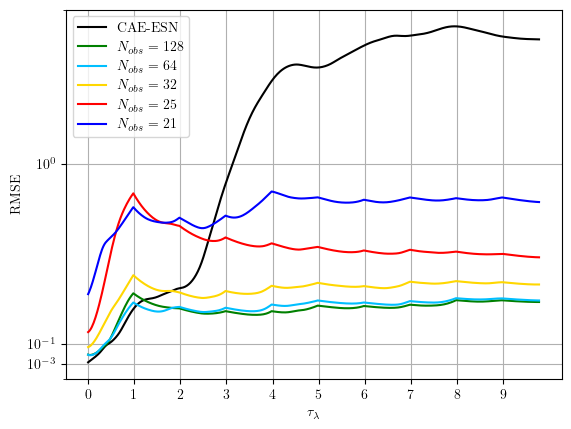

<Figure size 500x300 with 0 Axes>

In [ ]:
def rmse(data1, data2):
    return np.sqrt(np.mean((data1 - data2) ** 2))

N_plot = 10 * N_lyap - 10

# Compute cumulative RMSE over time
rmse_time_caeesn = [rmse(data1[:i, :], data2[:i, :]) for i in range(2, N_plot + 2)]
plt.plot(lyapunov_time[:N_plot], rmse_time_caeesn, label="CAE-ESN", color="k")

for idx, sampling in enumerate( [1, 2, 4, 5, 6]):
    predictions = predictions_all_sampling[sampling]
    mean_prediction = np.mean(predictions[:, :, :], axis=0)  # Compute mean prediction
    decoded_pred_obs = cae_model.decoder(torch.from_numpy(mean_prediction[:len(time_prediction), :]).float().to(device)).numpy(force=True)*maxnorm
    data5 = decoded_pred_obs[N_washout:, 0 ] 
    rmse_time = [rmse(data1[1:i, :], data5[1:i, :]) for i in range(2, N_plot + 2)]
    N_obs = 128 // obs_sampling 
    plt.plot(lyapunov_time[:N_plot], rmse_time,  color = colors_alpha[-idx], label=f"$N_{{obs}}={N_obs}$")

plt.xlabel(r"$\tau_{\lambda}$")
plt.ylabel("RMSE")
plt.yscale("symlog")
plt.yticks([0.001, 0.1, 1.0])
plt.xticks(range(0, 10))
plt.legend()
plt.grid(True)
plt.figure(figsize=(5, 3))

# for fmt in ["pdf", "eps", "png"]:
    # plt.savefig(f'../images/ks_caeesnenkf_rmse_time_samples02.{fmt}', format=fmt, dpi=100, bbox_inches='tight')

In [ ]:
# predictions_all_sampling_std01[2] = predictions_all_sampling[2]

In [ ]:
# predictions_all_sampling_std01 = predictions_all_sampling

In [ ]:
predictions_all_sampling_std02= predictions_all_sampling

<Figure size 500x300 with 0 Axes>

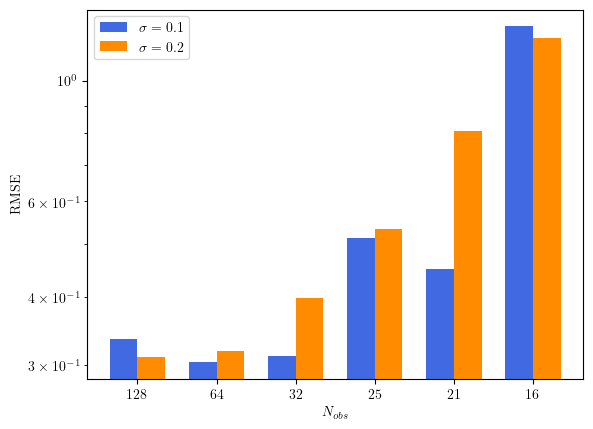

<Figure size 500x300 with 0 Axes>

In [ ]:
N_plot = 10 * N_lyap  
rmse_values_std01 = []  
rmse_values_std02 = []  
N_obs_values = []  

for sampling in [1, 2, 4, 5, 6, 8]:
    # Compute RMSE for std01
    mean_prediction_std01 = np.mean(predictions_all_sampling_std01[sampling], axis=0)  
    decoded_pred_obs_std01 = cae_model.decoder(torch.from_numpy(mean_prediction_std01[:len(time_prediction), :])
                                               .float().to(device)).numpy(force=True) * maxnorm  
    data5_std01 = decoded_pred_obs_std01[N_washout:, 0]  
    rmse_values_std01.append(rmse(data1[1:N_plot, :], data5_std01[1:N_plot, :]))  

    # Compute RMSE for std02
    mean_prediction_std02 = np.mean(predictions_all_sampling_std02[sampling], axis=0)  
    decoded_pred_obs_std02 = cae_model.decoder(torch.from_numpy(mean_prediction_std02[:len(time_prediction), :])
                                               .float().to(device)).numpy(force=True) * maxnorm  
    data5_std02 = decoded_pred_obs_std02[N_washout:, 0]  
    rmse_values_std02.append(rmse(data1[1:N_plot, :], data5_std02[1:N_plot, :]))  

    N_obs_values.append(128 // sampling)  

x = np.arange(len(N_obs_values))  # Evenly spaced x positions  
bar_width = 0.35  

# Plot both bars side by side
plt.bar(x - bar_width/2, rmse_values_std01, color="royalblue", width=bar_width, label=r"$\sigma=0.1$")  
plt.bar(x + bar_width/2, rmse_values_std02, color="darkorange", width=bar_width, label=r"$\sigma=0.2$")  

plt.xticks(x, N_obs_values)  # Set x-axis labels to actual N_obs values  
plt.xlabel("$N_{obs}$")  
plt.ylabel("RMSE")  
plt.yscale("log")  
plt.legend()  
plt.figure(figsize=(5, 3))
# plt.grid()#axis="y", linestyle="--", alpha=0.)  
# for fmt in ["pdf", "eps", "png"]:
#     plt.savefig(f'../images/ks_caeesnenkf_rmse_samples0102_nonlog.{fmt}', format=fmt, dpi=100, bbox_inches='tight')

In [ ]:
# fig, axes = plt.subplots(1, 2, figsize=(6, 3))  # Create two side-by-side subplots

# # --- First subplot: RMSE over time ---
# N_plot = 10 * N_lyap - 10
# rmse_time_caeesn = [rmse(data1[:i, :], data2[:i, :]) for i in range(2, N_plot + 2)]
# axes[0].plot(lyapunov_time[:N_plot], rmse_time_caeesn, label="CAE-ESN", color="k")

# for idx, sampling in enumerate([1, 2, 4, 5, 6]):
#     predictions = predictions_all_sampling[sampling]
#     mean_prediction = np.mean(predictions, axis=0)
#     decoded_pred_obs = cae_model.decoder(torch.from_numpy(mean_prediction[:len(time_prediction), :])
#                                          .float().to(device)).numpy(force=True) * maxnorm
#     data5 = decoded_pred_obs[N_washout:, 0]
#     rmse_time = [rmse(data1[1:i, :], data5[1:i, :]) for i in range(2, N_plot + 2)]
#     N_obs = 128 // sampling
#     axes[0].plot(lyapunov_time[:N_plot], rmse_time, color=colors_alpha[-idx], label=f"$N_{{obs}}={N_obs}$")

# axes[0].set_xlabel(r"$\tau_{\lambda}$")
# axes[0].set_ylabel("RMSE")
# axes[0].set_yscale("symlog")
# axes[0].set_yticks([0.001, 0.1, 1.0])
# axes[0].set_xticks(range(0, 10))
# axes[0].legend()
# axes[0].grid(True)

# # --- Second subplot: Bar plot of RMSE ---
# N_plot = 10 * N_lyap
# rmse_values_std01 = []
# rmse_values_std02 = []
# N_obs_values = []

# for sampling in [1, 2, 4, 5, 6, 8]:
#     # Compute RMSE for std01
#     mean_prediction_std01 = np.mean(predictions_all_sampling_std01[sampling], axis=0)
#     decoded_pred_obs_std01 = cae_model.decoder(torch.from_numpy(mean_prediction_std01[:len(time_prediction), :])
#                                                .float().to(device)).numpy(force=True) * maxnorm
#     data5_std01 = decoded_pred_obs_std01[N_washout:, 0]
#     rmse_values_std01.append(rmse(data1[1:N_plot, :], data5_std01[1:N_plot, :]))

#     # Compute RMSE for std02
#     mean_prediction_std02 = np.mean(predictions_all_sampling_std02[sampling], axis=0)
#     decoded_pred_obs_std02 = cae_model.decoder(torch.from_numpy(mean_prediction_std02[:len(time_prediction), :])
#                                                .float().to(device)).numpy(force=True) * maxnorm
#     data5_std02 = decoded_pred_obs_std02[N_washout:, 0]
#     rmse_values_std02.append(rmse(data1[1:N_plot, :], data5_std02[1:N_plot, :]))

#     N_obs_values.append(128 // sampling)

# x = np.arange(len(N_obs_values))
# bar_width = 0.35

# axes[1].bar(x - bar_width/2, rmse_values_std01, color="royalblue", width=bar_width, label=r"$\sigma=0.1$")
# axes[1].bar(x + bar_width/2, rmse_values_std02, color="darkorange", width=bar_width, label=r"$\sigma=0.2$")

# axes[1].set_xticks(x)
# axes[1].set_xticklabels(N_obs_values)
# axes[1].set_xlabel("$N_{obs}$")
# axes[1].set_ylabel("RMSE")
# axes[1].set_yscale("log")
# axes[1].legend()
# axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# plt.tight_layout()  # Adjust layout to prevent overlap
# plt.show()


/tmp/ipykernel_833463/981684000.py:22: UserWarning: All values for SymLogScale are below linthresh, making it effectively linear. You likely should lower the value of linthresh. 
  plt.yticks([0.001, 0.1, 1.0])


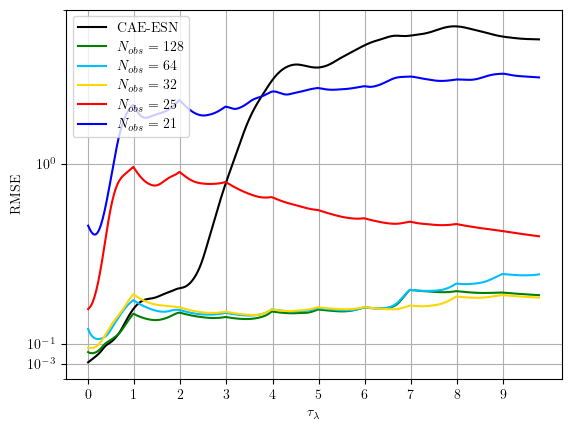

In [ ]:
def rmse(data1, data2):
    return np.sqrt(np.mean((data1 - data2) ** 2))

N_plot = 10 * N_lyap - 10

# Compute cumulative RMSE over time
rmse_time_caeesn = [rmse(data1[:i, :], data2[:i, :]) for i in range(2, N_plot + 2)]
plt.plot(lyapunov_time[:N_plot], rmse_time_caeesn, label="CAE-ESN", color="k")

for idx, sampling in enumerate( [1, 2, 4, 5, 6]):
    predictions = predictions_all_sampling[sampling]
    mean_prediction = np.mean(predictions[:, :, :], axis=0)  # Compute mean prediction
    decoded_pred_obs = cae_model.decoder(torch.from_numpy(mean_prediction[:len(time_prediction), :]).float().to(device)).numpy(force=True)*maxnorm
    data5 = decoded_pred_obs[N_washout:, 0 ] 
    rmse_time = [rmse(data1[1:i, :], data5[1:i, :]) for i in range(2, N_plot + 2)]
    N_obs = 128 // sampling 
    plt.plot(lyapunov_time[:N_plot], rmse_time,  color = colors_alpha[-idx], label=f"$N_{{obs}}={N_obs}$")

plt.xlabel(r"$\tau_{\lambda}$")
plt.ylabel("RMSE")
plt.yscale("symlog")
plt.yticks([0.001, 0.1, 1.0])
plt.xticks(range(0, 10))
plt.legend()
plt.grid(True)

# for fmt in ["pdf", "eps", "png"]:
#     plt.savefig(f'../images/ks_caeesnenkf_rmse_time_samples.{fmt}', format=fmt, dpi=100, bbox_inches='tight')

In [ ]:
# Formatter for x-axis ticks as multiples of pi
def pi_formatter(x, pos):
    n = x / np.pi
    if np.isclose(n, 0):
        return "0"
    elif np.isclose(n, 1):
        return r"$\pi$"
    elif np.isclose(n % 1, 0):
        return fr"${int(n)}\pi$"
    else:
        return ""

/tmp/ipykernel_2972500/549505563.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Leave room for colorbar


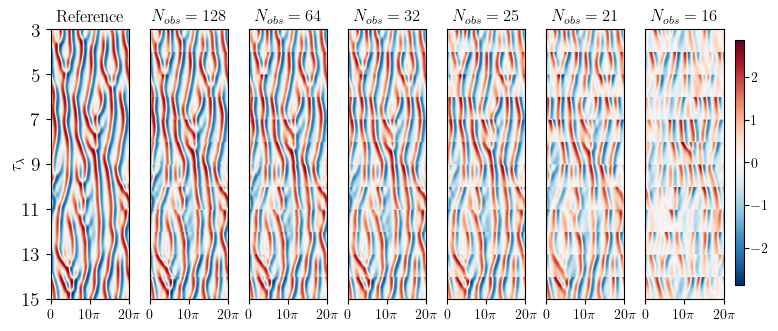

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter

# Define RMSE function
def rmse(data1, data2):
    return np.sqrt(np.mean((data1 - data2) ** 2))

# Constants
N_plot = 12 * N_lyap
sampling_values = [1, 2, 4, 5, 6, 8]
cmap = 'RdBu_r'
xticks = np.arange(0, 21 * np.pi, 10 * np.pi)

# Lyapunov time axis
lyapunov_time = 0.08 * np.arange(0, 10000, (ks_data["dt"] * ks_data["upsample"]))

# Decode ground truth
snapshot = cae_model.decoder(
    torch.from_numpy(truth[:len(time_prediction), :]).float().to(device)
).numpy(force=True) * maxnorm
data1 = snapshot[N_washout:N_washout + N_plot, 0, :]

# Decode CAE-ESN prediction
washout_snapshots_caeesn = U_test_series[N_start+N_washout:N_start + 2*N_washout]
washout_encoded_caeesn = cae_model.encoder(
    torch.from_numpy(washout_snapshots_caeesn).float().to(device)
).numpy(force=True)
_, reservoir_prediction = my_ESN.closed_loop_with_washout(
    washout_encoded_caeesn, obs_ensemble.shape[1] + N_washout
)
cae_esn_pred_decoded = cae_model.decoder(
    torch.from_numpy(reservoir_prediction).float().to(device)
).numpy(force=True) * maxnorm

# Color range
vmin = -0.8 * maxnorm
vmax = 0.8 * maxnorm

# GridSpec setup
fig = plt.figure(figsize=(9, 3.5))
gs = gridspec.GridSpec(1, len(sampling_values) + 2, width_ratios=[1]*(len(sampling_values)+1) + [0.05], wspace=0.3)

# Ground truth
ax0 = fig.add_subplot(gs[0])
im = ax0.imshow(data1, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                extent=[0, 2 * 10 * np.pi, int(lyapunov_time[N_plot]), lyapunov_time[0]])
ax0.set_title("Reference")
ax0.set_xticks(xticks)
ax0.xaxis.set_major_formatter(FuncFormatter(pi_formatter))
ax0.set_ylabel(r'$\tau_{\lambda}$', fontsize=12, labelpad=-2)

yticks = ax0.get_yticks()
ax0.set_yticks(yticks)
ax0.set_yticklabels([f'{int(tick + 3)}' for tick in yticks], fontsize=fs)


# Predictions for different sampling
for idx, sampling in enumerate(sampling_values[:]):
    ax = fig.add_subplot(gs[idx+1])
    predictions = predictions_all_sampling[sampling]
    mean_prediction = np.mean(predictions, axis=0)
    decoded_pred = cae_model.decoder(
        torch.from_numpy(mean_prediction[:len(time_prediction), :]).float().to(device)
    ).numpy(force=True) * maxnorm

    data_pred = decoded_pred[N_washout:N_washout + N_plot, 0, :]
    im = ax.imshow(data_pred, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   extent=[0, 2 * 10 * np.pi, int(lyapunov_time[N_plot]), lyapunov_time[0]])

    N_obs = 128 // sampling
    ax.set_title(f"$N_{{obs}}={N_obs}$")
    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))
    ax.set_yticks([])


# Colorbar
cbar_ax = fig.add_axes([0.885, 0.15, 0.01, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.tick_params(labelsize=10, pad=2)

plt.tight_layout()  # Leave room for colorbar
# # plt.savefig(...)

plt.savefig(f'../images/ks/v2/ks_caeesnenkf_dec_samples.pdf', format='pdf', dpi=200, bbox_inches='tight')
plt.savefig(f'../images/ks/v2/ks_caeesnenkf_dec_samples.eps', format='eps', dpi=200, bbox_inches='tight')
plt.savefig(f'../images/ks/v2/ks_caeesnenkf_dec_samples.png', format='png', dpi=200, bbox_inches='tight')


In [ ]:
N_as= 40
N_steps = 50 //2
 # Set seed for reproducibility
np.random.seed(1)
# Kalman Parameters
# N_steps = 100 #int(np.mean((locations[1:]-locations[:-1])))#s locations[-1]//N_as
washout_snapshots = U_test_series[N_start:N_start + N_washout]
washout_encoded = cae_model.encoder(torch.from_numpy(washout_snapshots).float().to(device)).numpy(force=True)
truth = U_test[N_start + N_washout: N_start + N_washout+N_as*N_steps*2, :]
# true_vorticity = U_test_series[N_start + N_washout: N_start + N_washout+N_as*N_steps*2, :]
true_encoded, true_vorticity = cae_model(torch.from_numpy(U_test_series[N_start + N_washout: N_start + N_washout+N_as*N_steps*2, :]).float().to(device))
true_encoded = true_encoded.numpy(force=True)
true_vorticity = true_vorticity.numpy(force=True)
sigma_obs = 0.05
# washout_noise_ensemble = add_noise(np.ones(shape=(N_washout, latentdim))*washout_encoded[-1, :], sigma_obs * np.std(U_encoded, axis=0), (N_ensemble, N_washout, latentdim))

washout_noise_ensemble = np.array([U_train_input[randint:randint+N_washout] for randint in np.random.randint(0, U_train_input.shape[0]-2*N_washout, N_ensemble)])
sigma_obs=0.1
vorticity_obs_ensemble = true_vorticity[:, 0, :] + np.random.normal(loc=0, scale=sigma_obs * np.std(U_test_series, axis=0), size=(N_ensemble, true_vorticity.shape[0], true_vorticity.shape[-1]))

sampling = 5
dim_sampling = 128 //sampling
selected_columns = np.arange(-dim_sampling * sampling, 0, step=sampling)
M = np.zeros(shape=(dim_sampling,  esn_dict["reservoir_size"]+128))
M[-dim_sampling:, selected_columns] = np.eye(dim_sampling)


Cdd = calculate_observation_error_covariance(vorticity_obs_ensemble[::obs_sampling, :])

reservoir_size = esn_dict["reservoir_size"]
obs_ensemble = np.zeros((N_ensemble, N_steps, reservoir_size ))
obs_ensemble_step = np.zeros((N_ensemble, N_steps, reservoir_size ))
predictions = np.zeros((N_ensemble, N_steps, latentdim))
# bias = np.repeat((my_ESN.W_out[esn_dict["reservoir_size"]:] * my_ESN.b_out), N_as=N_ensemble, axis=0).T
obs_ensemble = np.zeros((N_ensemble, 1, reservoir_size ))
predictions_at = np.zeros((N_ensemble, 1, latentdim))
measurements = truth[0:1]
locations = 0


for i in range(N_ensemble):
    reservoir, prediction = my_ESN.closed_loop_with_washout( washout_noise_ensemble[i], N_steps)
    obs_ensemble_step[i] = reservoir[1:] #reservoir_with_bias(reservoir[1:], my_ESN.b_out)
    predictions[i] = prediction[1:]


for j in range(N_as):

    measurement_idx = N_steps
    obs_ensemble = np.append(obs_ensemble, obs_ensemble_step[:, :measurement_idx], axis=1)
    predictions_at = np.append(predictions_at, predictions[:, :measurement_idx], axis=1)

    print(measurement_idx, obs_ensemble.shape[1] - 1)
    sample_loc =  obs_ensemble.shape[1] - 1
    measurements = np.append(measurements, truth[sample_loc:sample_loc+1], axis=0)
    locations = np.append(locations, sample_loc)

    augmented_state = np.append(obs_ensemble[:, -1, :esn_dict["reservoir_size"]].T, cae_model.decoder(torch.from_numpy(predictions[:, -1, :]).float().to(device)).numpy(force=True).T[:, 0,:], axis=0)
    #  observations_ensemble_new[:, sample_loc, :].T  - bias
    measurement_vorticity =vorticity_obs_ensemble[:,sample_loc, :].T[selected_columns, :]
    Aa = EnKF(Af=augmented_state, d=measurement_vorticity, Cdd=Cdd[selected_columns, :][:, selected_columns], M=M)

    for i in range(N_ensemble):
        reservoir, prediction = my_ESN.closed_loop(Aa[: esn_dict["reservoir_size"], i], N_steps)
        obs_ensemble_step[i] = reservoir[1:] #reservoir_with_bias(reservoir[1:], my_ESN.b_out) 
        predictions[i] = prediction[1:]

measurement_idx = N_steps
print(measurement_idx)
obs_ensemble = np.append(obs_ensemble[:, 1:, :], obs_ensemble_step[:, :measurement_idx], axis=1)
predictions_at = np.append(predictions_at[:, 1:, :], predictions[:, :measurement_idx], axis=1)
measurements = measurements[1:]
locations = locations[1:] + N_washout


KeyboardInterrupt: 

In [ ]:
128 /8

16.0

In [ ]:
lyapunov_time = 0.08 * np.arange(0, 10000, (ks_data["dt"]*ks_data["upsample"]))
lyapunov_time[600]

12.0

Mean pointwise error: 0.25567302107810974


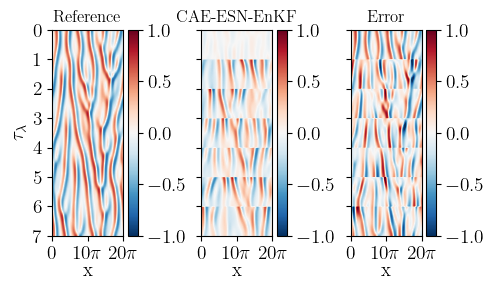

In [ ]:
# Define constants
reservoir, reservoir_prediction = my_ESN.closed_loop_with_washout(
    washout_observations, obs_ensemble.shape[1] + N_washout
)
cmap = 'RdBu_r'
fs = 14
# Calculate domain length
domain_length = 20 * np.pi
N_plot = len(time_prediction)-200#60*N_lyap#len(time_prediction)
# Create subplots
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(5,3), sharey=True)  # Changed ncols to 1
mean_prediction = np.mean(predictions, axis=0)
snapshot_decoded = cae_model.decoder(torch.from_numpy(mean_prediction).float().to(device)).numpy(force=True)
snapshot = cae_model.decoder(torch.from_numpy(truth[:len(time_prediction), :]).float().to(device)).numpy(force=True)


# Extract data
data1 = snapshot[:N_plot, 0, :] 
data2 = snapshot_decoded[:N_plot, 0, :] 
data3 = data1 - data2
# Calculate global vmin and vmax
vmin = -1# min(data1.min(), data2.min(), data3.min())
vmax = 1 #max(data1.max(), data2.max(), data3.max())

lyapunov_time = 0.08 * np.arange(0, 10000, (ks_data["dt"]*ks_data["upsample"]))
# Adjust subplot spacing
plt.subplots_adjust(wspace=-0.05)  #
# Plot data
for i, data in enumerate([data1, data2, data3]):
    axes = axs[i]
    im = axes.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                     extent=[0, 2 * 10 * np.pi, int(lyapunov_time[N_plot]), lyapunov_time[0]])


    axes.set_xlabel('x', fontsize=fs, rotation=0, labelpad=0, y=0.46)
     # Set y-tick labels and font size
    axes.set_yticks(axes.get_yticks())  # Ensure yticks are set first
    axes.set_yticklabels([f'{int(tick)}' for tick in axes.get_yticks()], fontsize=fs)

    axes.yaxis.tick_left()
    axes.set_xticks(np.arange(0, 20 * np.pi + 0.01, step=(1 * 10 * np.pi)), ['0', r'$10\pi$', r'20$\pi$'],
                    fontsize=fs)
    for tick_label in axes.get_xticklabels():
        tick_label.set_ha('center')
        tick_label.set_x(-0.05)

    cbar = fig.colorbar(im, ax=axes)
    cbar.ax.tick_params(labelsize=fs)

axs[0].set_ylabel(r'$\tau_{\lambda}$', fontsize=fs)
axs[0].set_title("Reference")
axs[1].set_title("CAE-ESN-EnKF")
axs[2].set_title("MAE")
# Show or save plot
plt.tight_layout()
print(f"Mean pointwise error: {np.mean(np.abs(data3[:, :]))}")

In [ ]:
128/24

5.333333333333333

In [ ]:
N_as= 30
N_steps = N_lyap//4
 # Set seed for reproducibility
np.random.seed(1)
washout_snapshots=U_test_series[N_start:N_start + N_washout]
washout_encoded = cae_model.encoder(torch.from_numpy(washout_snapshots).float().to(device)).numpy(force=True)
truth = U_test[N_start + N_washout: N_start + N_washout+N_as*N_steps*2, :]
# true_vorticity = U_test_series[N_start + N_washout: N_start + N_washout+N_as*N_steps*2, :]
true_encoded, true_vorticity = cae_model(torch.from_numpy(U_test_series[N_start + N_washout: N_start + N_washout+N_as*N_steps*2, :]).float().to(device))
true_encoded = true_encoded.numpy(force=True)
true_vorticity = true_vorticity.numpy(force=True)
sigma_obs = 0.05
washout_noise_ensemble =np.array([U_train_input[randint:randint+N_washout] for randint in np.random.randint(0, U_train_input.shape[0]-2*N_washout, N_ensemble)]) # add_noise(washout_encoded, sigma_obs * np.std(U_encoded, axis=0), (N_ensemble, N_washout, latentdim))
sigma_obs=0.001
vorticity_obs_ensemble = true_vorticity[:, 0, :] + np.random.normal(loc=0, scale=sigma_obs * np.std(U_test_series, axis=0), size=(N_ensemble, true_vorticity.shape[0], true_vorticity.shape[-1]))

sampling=1
dim_sampling = 128 //sampling
selected_columns = np.arange(-dim_sampling * sampling, 0, step=sampling)
M = np.zeros(shape=(dim_sampling,  esn_dict["reservoir_size"]+128))
M[-dim_sampling:, selected_columns] = np.eye(dim_sampling)

Cdd = calculate_observation_error_covariance(vorticity_obs_ensemble)

reservoir_size = esn_dict["reservoir_size"]
obs_ensemble = np.zeros((N_ensemble, N_steps, reservoir_size ))
obs_ensemble_step = np.zeros((N_ensemble, N_steps, reservoir_size ))
predictions = np.zeros((N_ensemble, N_steps, latentdim))
# bias = np.repeat((my_ESN.W_out[esn_dict["reservoir_size"]:] * my_ESN.b_out), N_as=N_ensemble, axis=0).T
obs_ensemble = np.zeros((N_ensemble, 1, reservoir_size ))
predictions_at = np.zeros((N_ensemble, 1, latentdim))
measurements = truth[0:1]
locations = 0


for i in range(N_ensemble):
    reservoir, prediction = my_ESN.closed_loop_with_washout( washout_noise_ensemble[i], N_steps)
    obs_ensemble_step[i] = reservoir[1:] #reservoir_with_bias(reservoir[1:], my_ESN.b_out)
    predictions[i] = prediction[1:]


for j in range(N_as):

    measurement_idx = N_steps
    obs_ensemble = np.append(obs_ensemble, obs_ensemble_step[:, :measurement_idx], axis=1)
    predictions_at = np.append(predictions_at, predictions[:, :measurement_idx], axis=1)

    print(measurement_idx, obs_ensemble.shape[1] - 1)
    sample_loc =  obs_ensemble.shape[1] - 1
    measurements = np.append(measurements, truth[sample_loc:sample_loc+1], axis=0)
    locations = np.append(locations, sample_loc)

    augmented_state = np.append(obs_ensemble[:, -1, :esn_dict["reservoir_size"]].T, cae_model.decoder(torch.from_numpy(predictions[:, -1, :]).float().to(device)).numpy(force=True).T[:, 0,:], axis=0)
    #  observations_ensemble_new[:, sample_loc, :].T  - bias
    measurement_vorticity = vorticity_obs_ensemble[:,sample_loc, :].T[selected_columns, :]
    Aa = EnKF(Af=augmented_state, d=measurement_vorticity, Cdd=Cdd[selected_columns, :][:, selected_columns], M=M)

    for i in range(N_ensemble):
        reservoir, prediction = my_ESN.closed_loop(Aa[: esn_dict["reservoir_size"], i], N_steps)
        obs_ensemble_step[i] = reservoir[1:] #reservoir_with_bias(reservoir[1:], my_ESN.b_out) 
        predictions[i] = prediction[1:]

measurement_idx = N_steps
print(measurement_idx)
obs_ensemble = np.append(obs_ensemble[:, 1:, :], obs_ensemble_step[:, :measurement_idx], axis=1)
predictions_at = np.append(predictions_at[:, 1:, :], predictions[:, :measurement_idx], axis=1)
measurements = measurements[1:]
locations = locations[1:] + N_washout


12 12
12 24
12 36
12 48
12 60
12 72
12 84
12 96
12 108
12 120
12 132
12 144
12 156
12 168
12 180
12 192
12 204
12 216
12 228
12 240
12 252
12 264
12 276
12 288
12 300
12 312
12 324
12 336
12 348
12 360
12


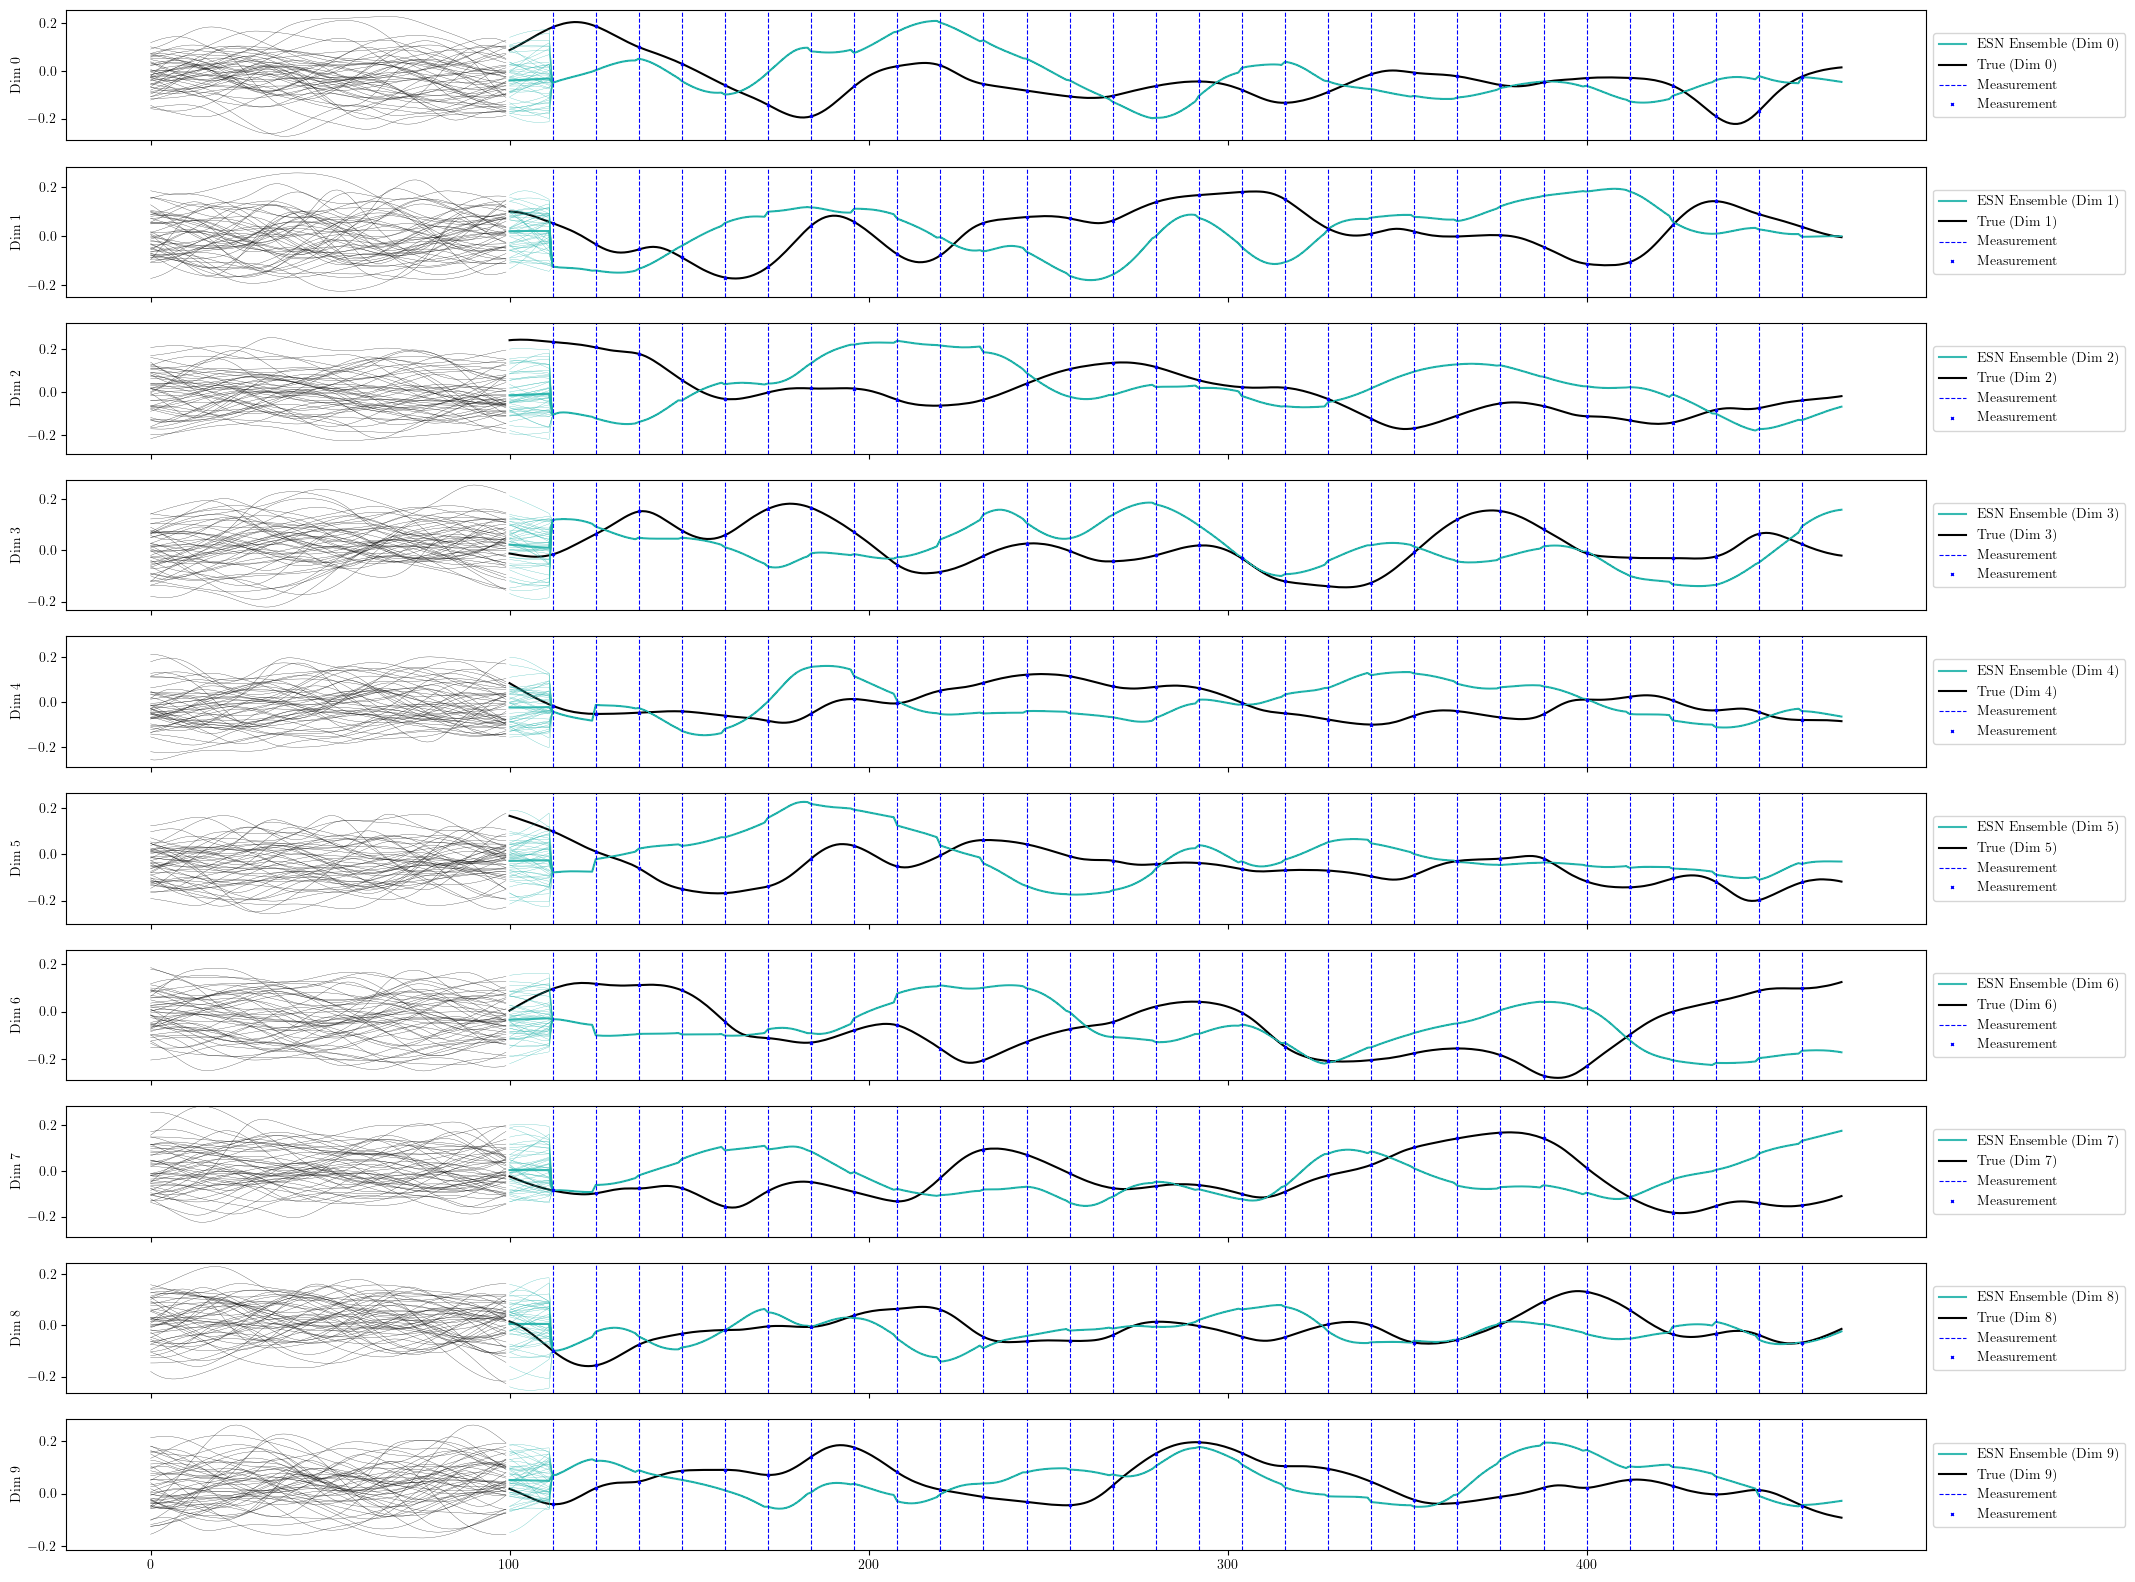

In [ ]:
dt = 1# ks_data["lyap"] * (ks_data["dt"]*ks_data["upsample"])
time_prediction = np.arange(N_washout, obs_ensemble.shape[1] + N_washout) * dt
time_washout = np.arange(0, N_washout) * dt
time_A_tracked = np.arange(N_washout, obs_ensemble.shape[1] + N_washout, step=N_steps) * dt
measurements = measurements[:N_as]

# Define the number oflatentdimensions based on the predictions array
N_dims = 10
fig, axs = plt.subplots(N_dims, 1, figsize=(24, 2 * N_dims), sharex=True)
time_prediction = np.arange(N_washout, obs_ensemble.shape[1] + N_washout) * dt
time_washout = np.arange(0, N_washout) * dt

predictions = (obs_ensemble @ my_ESN.W_out)

forlatentdim in range(N_dims):
    axs[dim].plot(time_prediction, np.mean(predictions[:, :,latentdim], axis=0), color=color_bias, label=f"ESN Ensemble (Dim {dim})")
    axs[dim].plot(time_prediction, truth[:len(time_prediction),latentdim], "k", label=f"True (Dim {dim})")
    
    for mi in range(obs_ensemble.shape[0]):
        axs[dim].plot(time_washout, washout_noise_ensemble[mi, :,latentdim], **washout_ens_props)
        axs[dim].plot(time_prediction, predictions[mi, :,latentdim], **esn_ens_props)
        # axs[dim].plot(time_A_tracked[1:], Aa_tracked[:,latentdim, mi], ".", color="r", markersize=2)
    for loc in locations:
        axs[dim].axvline(
            x=loc,
            color="b",
            linestyle="--",
            linewidth=0.8,
            label="Measurement" if loc == locations[0] else None  # Avoid duplicate legend entries
        )
    axs[dim].plot(locations[:], measurements[:,latentdim],"x",color="b", markersize=2, label="Measurement",)
    # axs[dim].plot(time_A_tracked[:-1], measurements[:,latentdim], "x", color="b", markersize=6, label="Measurement")
    axs[dim].set_ylim(np.min(U_encoded[:,latentdim]), np.max(U_encoded[:,latentdim]))
    axs[dim].set_ylabel(f"Dim {dim}")
    axs[dim].legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

Mean pointwise error: 0.16902855038642883


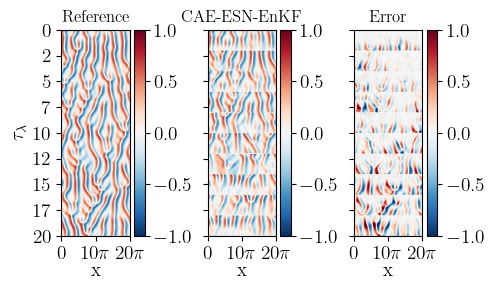

In [ ]:
# Define constants
reservoir, reservoir_prediction = my_ESN.closed_loop_with_washout(
    washout_observations, obs_ensemble.shape[1] + N_washout
)
cmap = 'RdBu_r'
fs = 14
# Calculate domain length
domain_length = 20 * np.pi
N_plot = 1000#60*N_lyap#len(time_prediction)
# Create subplots
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(5,3), sharey=True)  # Changed ncols to 1
mean_prediction = np.mean(predictions, axis=0)
snapshot_decoded = cae_model.decoder(torch.from_numpy(mean_prediction).float().to(device)).numpy(force=True)
snapshot = cae_model.decoder(torch.from_numpy(truth[:len(time_prediction), :]).float().to(device)).numpy(force=True)


# Extract data
data1 = snapshot[:N_plot, 0, :] 
data2 = snapshot_decoded[:N_plot, 0, :] 
data3 = data1 - data2
# Calculate global vmin and vmax
vmin = -1# min(data1.min(), data2.min(), data3.min())
vmax = 1 #max(data1.max(), data2.max(), data3.max())

lyapunov_time = 0.08 * np.arange(0, 10000, (ks_data["dt"]*ks_data["upsample"]))
# Adjust subplot spacing
plt.subplots_adjust(wspace=-0.05)  #
# Plot data
for i, data in enumerate([data1, data2, data3]):
    axes = axs[i]
    im = axes.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                     extent=[0, 2 * 10 * np.pi, int(lyapunov_time[N_plot]), lyapunov_time[0]])


    axes.set_xlabel('x', fontsize=fs, rotation=0, labelpad=0, y=0.46)
     # Set y-tick labels and font size
    axes.set_yticks(axes.get_yticks())  # Ensure yticks are set first
    axes.set_yticklabels([f'{int(tick)}' for tick in axes.get_yticks()], fontsize=fs)

    axes.yaxis.tick_left()
    axes.set_xticks(np.arange(0, 20 * np.pi + 0.01, step=(1 * 10 * np.pi)), ['0', r'$10\pi$', r'20$\pi$'],
                    fontsize=fs)
    for tick_label in axes.get_xticklabels():
        tick_label.set_ha('center')
        tick_label.set_x(-0.05)

    cbar = fig.colorbar(im, ax=axes)
    cbar.ax.tick_params(labelsize=fs)

axs[0].set_ylabel(r'$\tau_{\lambda}$', fontsize=fs)
axs[0].set_title("Reference")
axs[1].set_title("CAE-ESN-EnKF")
axs[2].set_title("Error")
# Show or save plot
plt.tight_layout()
print(f"Mean pointwise error: {np.mean(np.abs(data3[:, :]))}")

In [ ]:
128/8

16.0

In [ ]:
M = np.zeros(shape=(64, 10064))
M[-64:, -64:]  = np.eye(64)

In [ ]:

M @ augmented_state

array([[-0.36478516, -0.46553794, -0.3490797 , ..., -0.5117237 ,
        -0.26511529, -0.40188959],
       [-0.54210842, -0.55278003, -0.5518719 , ..., -0.53958559,
        -0.52339613, -0.55449492],
       [-0.38433906, -0.34745422, -0.40786833, ..., -0.31125444,
        -0.41375202, -0.38129711],
       ...,
       [ 0.37629721,  0.41439486,  0.38317835, ...,  0.43216506,
         0.33952424,  0.39563838],
       [ 0.50870681,  0.4880203 ,  0.5213058 , ...,  0.46641895,
         0.51772898,  0.5122937 ],
       [ 0.23120439,  0.08754379,  0.25824165, ..., -0.00913031,
         0.33380073,  0.19517304]])

In [ ]:
EnKF(Af=augmented_state, d=decoded_truth, Cdd=Cdd, M=M).shape

(10128, 50)

In [ ]:
decoded_truth.shape

(128, 50)

In [ ]:
.shape

(10128, 50)

In [ ]:
Aa

In [ ]:

with open(esn_path / 'best_dict.pkl', 'rb') as f:
    esn_dict = pickle.load(f)

print(f"Dictionary loaded in {esn_dict}")
i=0
my_ESN = ESN(reservoir_size=esn_dict["reservoir_size"],
               latentdimension=esn_dict["dimension"],
                reservoir_connectivity=esn_dict["reservoir_connectivity"],
                spectral_radius=esn_dict['spectral_radius'][i],
                input_scaling=esn_dict['input_scaling'][i],
                tikhonov=esn_dict['tikhonov'][i],
                input_bias=esn_dict["input_bias"],
                # output_bias=esn_dict["output_bias"],
                reservoir_weights_mode=esn_dict['reservoir_weights_mode'],
                input_normalization=esn_dict['input_normalization'],
                input_weights_mode=esn_dict['input_weights_mode'],
                #   leak_factor =min_dict['leak_factor'][i],
                input_seeds=esn_dict["input_seeds"],
                reservoir_seeds=esn_dict["reservoir_seeds"], verbose=False)
my_ESN.train(U_washout, U_train_input, U_train_label)

Dictionary loaded in {'reservoir_size': 10000, 'dimension': 24, 'reservoir_connectivity': 10, 'input_bias': array([1]), 'output_bias': array([1]), 'reservoir_weights_mode': 'erdos_renyi1', 'input_normalization': [array([-0.02025265,  0.01439961,  0.01297114,  0.01548875, -0.01127492,
       -0.03855802, -0.01731199, -0.0031711 ,  0.00166765,  0.02641685,
       -0.01411585,  0.00059135, -0.00298552,  0.01881336, -0.02819976,
        0.0646842 ,  0.00668405, -0.01583485,  0.00734384, -0.04423165,
        0.01386078, -0.00682314, -0.01313387,  0.00210296]), array([0.52056384, 0.50828821, 0.55006361, 0.49101659, 0.5746316 ,
       0.53197999, 0.54016614, 0.5681395 , 0.49504697, 0.48802266,
       0.51666316, 0.5304976 , 0.48416032, 0.53360493, 0.50640764,
       0.51969442, 0.57376187, 0.4897536 , 0.59622993, 0.54940182,
       0.50665853, 0.51868226, 0.52756472, 0.55626925])], 'input_weights_mode': 'dense', 'input_seeds': [0, 1, 2], 'reservoir_seeds': [3, 4], 'f': array([1.32613118, 1.33

In [ ]:
# Kalman Parameters
np.random.seed(123)
sigma_obs=0.05
N_ensemble = 60
N_as = 10
N_steps = N_lyap
washout_size =N_washout

#input data
N_start =1000
washout_observations = U_test[N_start:N_start+washout_size, :latentdim]
truth =  U_test[washout_size+N_start:, :]

washout_noise_ensemble = washout_observations + np.random.normal(loc=0.0, scale=sigma_obs*np.std(U_encoded, axis=0), size=(N_ensemble, washout_size, latentdim))
observations_ensemble = truth[:, :latentdim] + np.random.normal(loc=0.0, scale=sigma_obs*np.std(U_encoded, axis=0), size=(N_ensemble, truth.shape[0], latentdim))
measurements = truth[::N_steps]
obs_ensemble = np.zeros(shape=(N_ensemble, N_steps, esn_dict["reservoir_size"]))
obs_ensemble_step = np.zeros(shape=(N_ensemble, N_steps, esn_dict["reservoir_size"]))
predictions = np.zeros((N_ensemble, N_steps, latentdim))
# bias = np.repeat((my_ESN.W_out[esn_dict["reservoir_size"]:] * my_ESN.b_out), N_as=N_ensemble, axis=0).T
predictions_at = np.zeros((N_ensemble, 1, latentdim))


Cdd = calculate_observation_error_covariance(observations_ensemble)# np.diag((sigma_obs * np.ones(latentdim))) #* np.max(abs(observations), axis=0) ** 2
M = my_ESN.W_out[:, :latentdim].T
Aa_tracked = np.zeros(shape=(N_as, latentdim, N_ensemble))

for i in range(N_ensemble):
    reservoir, prediction  = my_ESN.closed_loop_with_washout(washout_noise_ensemble[i], N_steps)
    obs_ensemble[i] = reservoir[1:] # np.append(prediction, reservoir, axis=1)
    predictions[i] = prediction[1:]

    
for j in range(N_as):
    n_t_current = obs_ensemble.shape[1]-1
    Aa = EnKF(Af=obs_ensemble[:, -1, :].T, d=observations_ensemble[:, n_t_current, :].T, Cdd=Cdd, M=M)
    Aa_tracked[j] = (Aa.T @ my_ESN.W_out).T
    
    for i in range(N_ensemble):
        reservoir, prediction  = my_ESN.closed_loop(Aa[:, i], N_steps)
        obs_ensemble_step[i] = reservoir[1:] #np.append(prediction[1:], reservoir[1:], axis=1)
    obs_ensemble = np.append(obs_ensemble, obs_ensemble_step, axis=1)


In [ ]:
dt = 1# ks_data["lyap"] * (ks_data["dt"]*ks_data["upsample"])

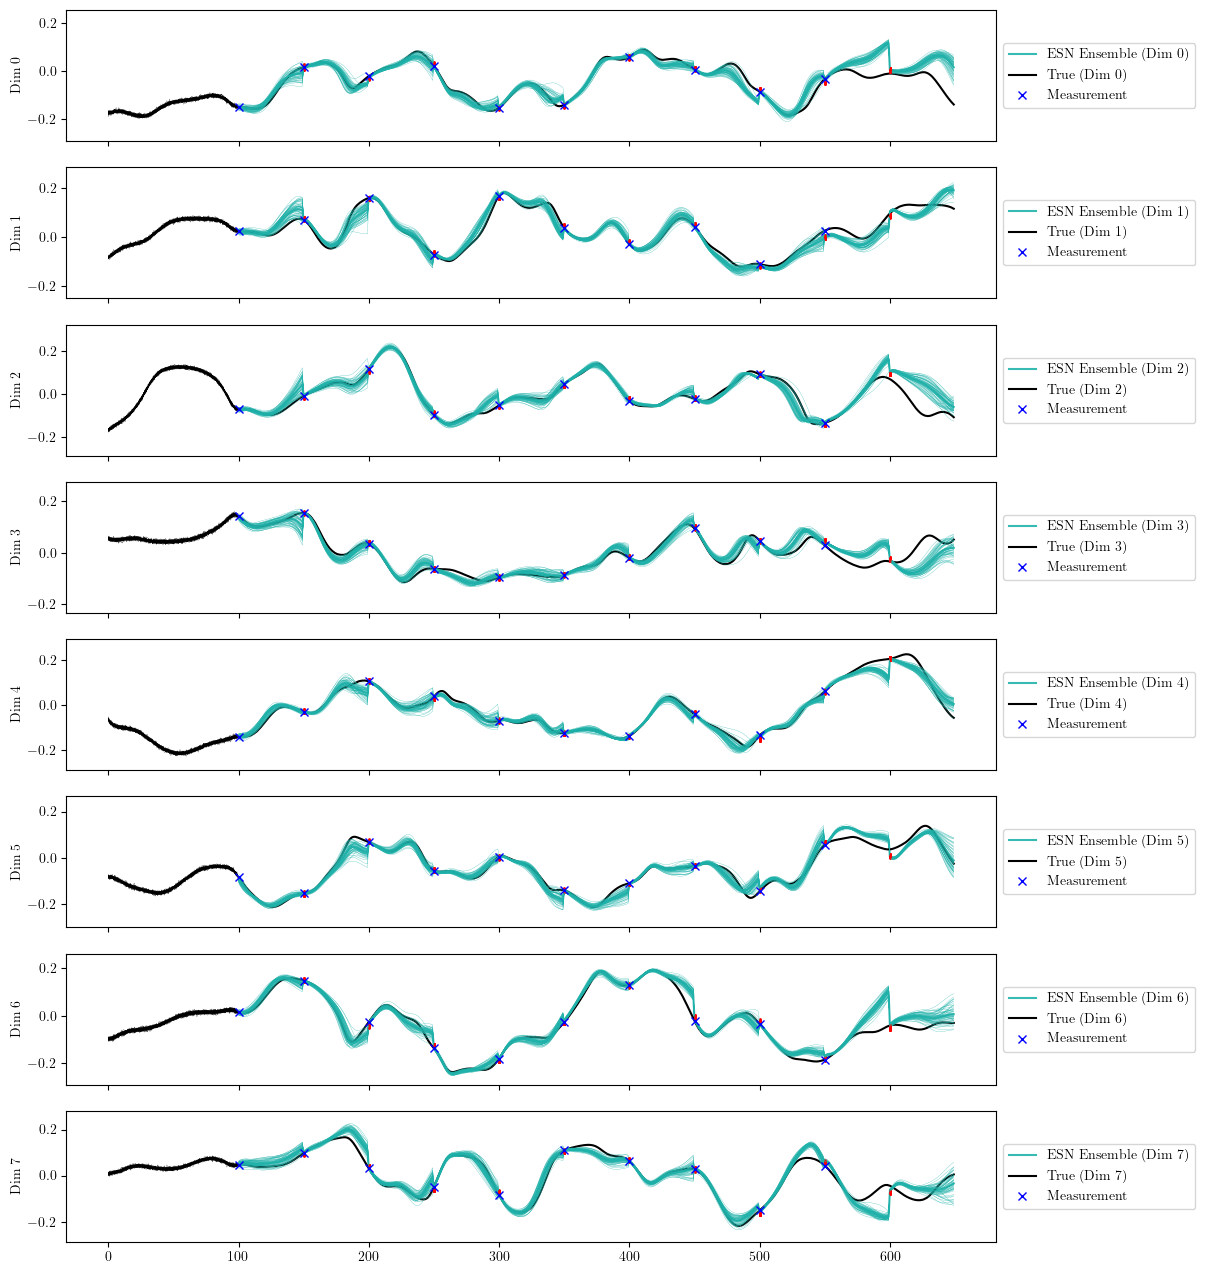

In [ ]:
time_A_tracked = np.arange(washout_size, obs_ensemble.shape[1] + washout_size, step=N_steps) * dt
measurements = measurements[:N_as]

# Define the number oflatentdimensions based on the predictions array
N_dims = 8

fig, axs = plt.subplots(N_dims, 1, figsize=(12, 2 * N_dims), sharex=True)
time_prediction = np.arange(washout_size, obs_ensemble.shape[1] + washout_size) * dt
time_washout = np.arange(0, washout_size) * dt

predictions = (obs_ensemble @ my_ESN.W_out)

forlatentdim in range(N_dims):
    axs[dim].plot(time_prediction, np.mean(predictions[:, :,latentdim], axis=0), color=color_bias, label=f"ESN Ensemble (Dim {dim})")
    axs[dim].plot(time_prediction, truth[:len(time_prediction),latentdim], "k", label=f"True (Dim {dim})")
    
    for mi in range(obs_ensemble.shape[0]):
        axs[dim].plot(time_washout, washout_noise_ensemble[mi, :,latentdim], **washout_ens_props)
        axs[dim].plot(time_prediction, predictions[mi, :,latentdim], **esn_ens_props)
        axs[dim].plot(time_A_tracked[1:], Aa_tracked[:,latentdim, mi], ".", color="r", markersize=2)
        
    axs[dim].plot(time_A_tracked[:-1], measurements[:,latentdim], "x", color="b", markersize=6, label="Measurement")
    axs[dim].set_ylim(np.min(U_encoded[:,latentdim]), np.max(U_encoded[:,latentdim]))
    axs[dim].set_ylabel(f"Dim {dim}")
    axs[dim].legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()


In [ ]:
mean_prediction = np.mean(predictions, axis=0)

/tmp/ipykernel_2900667/873571909.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


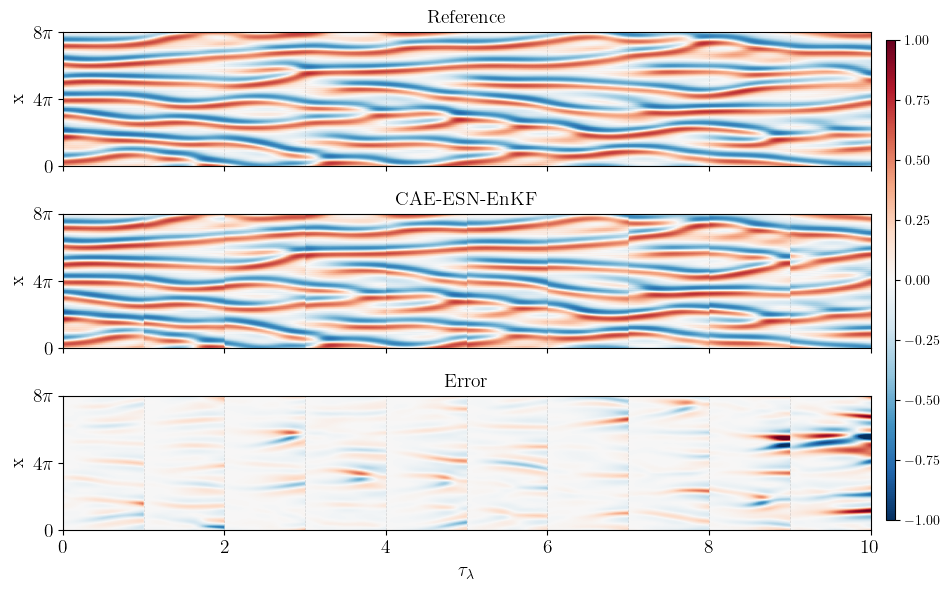

In [ ]:
mean_prediction = np.mean(predictions, axis=0)
snapshot_decoded = cae_model.decoder(torch.from_numpy(prediction).float().to(device)).numpy(force=True)
snapshot = cae_model.decoder(torch.from_numpy( u_encoded_test[N_start+N_washout:N_start+N_washout+N_plot, :]).float().to(device)).numpy(force=True)


# Define constants
cmap = 'RdBu_r'
fs = 14
domain_length = 8 * np.pi


# Create subplots
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(9, 6), sharex=True)  # Three subplots on top of each other

snapshot_decoded = cae_model.decoder(torch.from_numpy(mean_prediction).float().to(device)).numpy(force=True)
snapshot = cae_model.decoder(torch.from_numpy(truth[:len(time_prediction), :]).float().to(device)).numpy(force=True)
N_plot = 500
# Extract data
data1 = snapshot[:N_plot, 0, :] 
data2 = snapshot_decoded[:N_plot, 0, :] 
data3 = data1 - data2

# Calculate min and max values for color scale across all datasets
vmin = -1
vmax = 1
lyapunov_time = ks_data["t_lyap"] * np.arange(0, 10000, (ks_data["dt"] * ks_data["upsample"]))

# Adjust subplot spacing
plt.subplots_adjust(hspace=0.4)  # Adjust vertical space between plots

# Plot data with axis switched
for i, data in enumerate([data1, data2, data3]):
    axes = axs[i]
    im = axes.imshow(data.T, aspect='auto', cmap=cmap, origin='lower',
                     extent=[int(lyapunov_time[0]), (lyapunov_time[N_plot]), 0, 8 * np.pi],
                     vmin=vmin, vmax=vmax)  # Set color scale limits
    for x in lyapunov_time[:N_plot:N_steps]:
    #     if lyapunov_time[x] < int(lyapunov_time[N_plot]):
        axes.axvline(x=x, color='k', linestyle='--', linewidth=0.5, c="grey", alpha=0.3)


    # Set axis labels
    axes.set_ylabel('x', fontsize=fs)
    axes.set_yticks(np.arange(0, 8 * np.pi + 0.01, step=(1 * 4 * np.pi)))
    axes.set_yticklabels(['0', r'$4\pi$', r'$8\pi$'], fontsize=fs)

    axes.set_xticks(axes.get_xticks())
    axes.set_xticklabels([f'{int(tick)}' for tick in axes.get_xticks()], fontsize=fs)

# Add a single color bar for all plots
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([.99, 0.125, 0.01, .8])
fig.colorbar(im, cax=cbar_ax)

# Set titles and x-axis for the last plot
axs[0].set_title("Reference", fontsize=fs)
axs[1].set_title("CAE-ESN-EnKF", fontsize=fs)
axs[2].set_title("Error", fontsize=fs)

axs[2].set_xlabel(r'$\tau_{\lambda}$', fontsize=fs)  # Set xlabel on the last subplot
plt.tight_layout()
plt.show()



/tmp/ipykernel_2900667/610250089.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


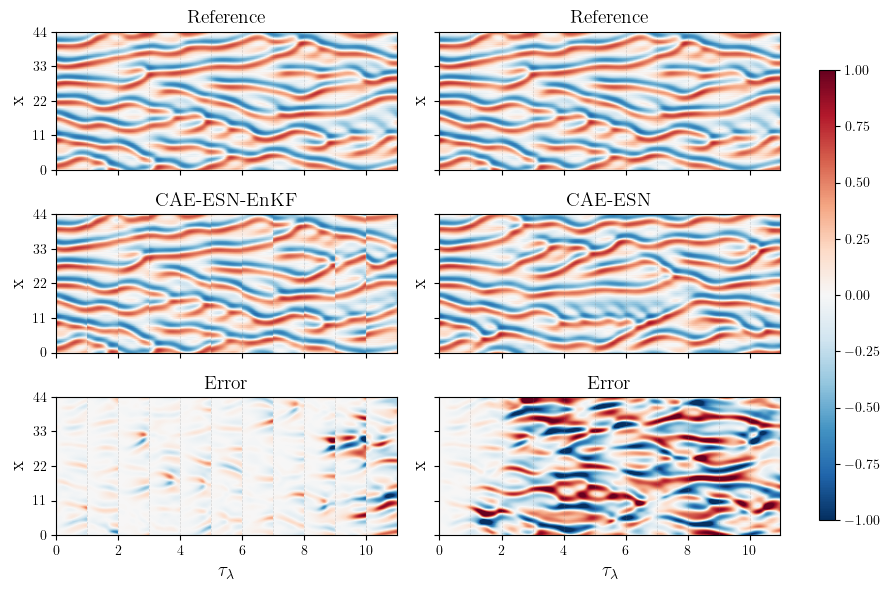

In [ ]:
# # Create a 3x2 subplot layout
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8, 6), sharex=True, sharey=True)  # Adjust width and height
axes = axs.flatten()
# # First dataset
mean_prediction = np.mean(predictions, axis=0)
snapshot_decoded1 = cae_model.decoder(torch.from_numpy(mean_prediction).float().to(device)).numpy(force=True)
snapshot1 = cae_model.decoder(torch.from_numpy(truth[:len(time_prediction), :]).float().to(device)).numpy(force=True)
N_plot = min(mean_prediction.shape[0], 20 * N_lyap)#len(time_prediction)
data1 = snapshot1[:N_plot, 0, :]
data2 = snapshot_decoded1[:N_plot, 0, :]
data3 = data1 - data2

# Second dataset
reservoir, prediction_esn = my_ESN.closed_loop_with_washout(washout_observations, N_plot+N_washout)
snapshot_decoded2 = cae_model.decoder(torch.from_numpy(prediction_esn).float().to(device)).numpy(force=True)
snapshot2 = cae_model.decoder(torch.from_numpy(truth).float().to(device)).numpy(force=True)
data4 = snapshot2[:N_plot, 0, :]
data5 = snapshot_decoded2[:N_plot, 0, :]
data6 = data4 - data5

# Set color scale limits and time axis
vmin, vmax = -1, 1
lyapunov_time = ks_data["t_lyap"] * np.arange(0, N_plot, (ks_data["dt"] * ks_data["upsample"]))
plt.subplots_adjust(hspace=0.4)  # Adjust vertical space between plots

cmap = 'RdBu_r'
# Define titles for the subplots
titles = ["Reference", "CAE-ESN-EnKF", "Error", "Reference", "CAE-ESN", "Error"]

# Plot data for each subplot
for i, data in enumerate([data1, data2, data3]):
   
    ax = axs[i, 0]
    im = ax.imshow(data.T, aspect='auto', cmap=cmap, origin='lower',
                   extent=[lyapunov_time[0], lyapunov_time[N_plot-1], 0, 44],
                   vmin=vmin, vmax=vmax)
    # Add vertical lines
    for x in lyapunov_time[:N_plot-1:N_steps]:
        ax.axvline(x=x, color='grey', linestyle='--', linewidth=0.5, alpha=0.3)

    # Set labels and title
    ax.set_title(titles[i], fontsize=fs)
    ax.set_ylabel('x', fontsize=fs)
    ax.set_yticks(np.arange(0, 44.01, step=11))
for i, data in enumerate([data4, data5, data6]):
    ax = axs[i, 1]
    im = ax.imshow(data.T, aspect='auto', cmap=cmap, origin='lower',
                   extent=[lyapunov_time[0], lyapunov_time[N_plot-1], 0, 44],
                   vmin=vmin, vmax=vmax)
    # Add vertical lines
    for x in lyapunov_time[:N_plot-1:N_steps]:
        ax.axvline(x=x, color='grey', linestyle='--', linewidth=0.5, alpha=0.3)

    # Set labels and title
    ax.set_title(titles[i+3], fontsize=fs)
    ax.set_ylabel('x', fontsize=fs)
    ax.set_yticks(np.arange(0, 44.01, step=11))

# Add a single color bar for all plots
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([1.03, 0.125, 0.02, 0.75])
fig.colorbar(im, cax=cbar_ax)

# Set x-axis label for the bottom row
axs[2, 0].set_xlabel(r'$\tau_{\lambda}$', fontsize=fs)
axs[2, 1].set_xlabel(r'$\tau_{\lambda}$', fontsize=fs)

plt.tight_layout()
# plt.show()

In [ ]:
maxnorm=3.58

/tmp/ipykernel_2900667/3539787307.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


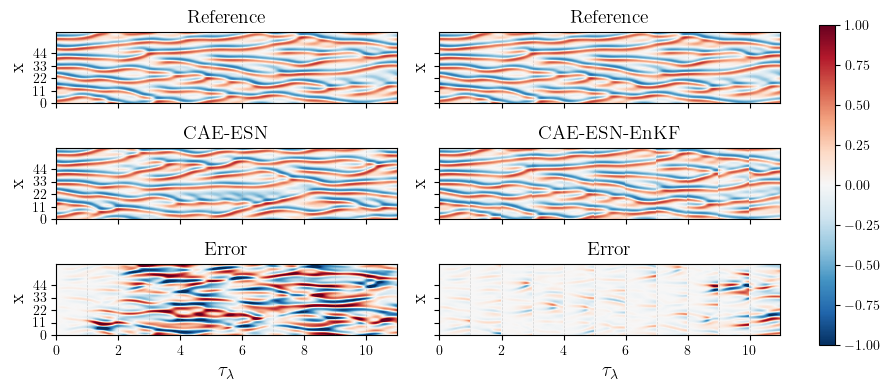

In [ ]:
# # Denormalize predictions using maxnorm
#  # Assuming 'truth' is normalized
# vmin =-maxnorm
# vmax = maxnorm
# data1 *= maxnorm
# data2 *= maxnorm
# data4 *= maxnorm
# data5 *= maxnorm

# Swap the sides
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8, 4), sharex=True, sharey=True)
axes = axs.flatten()
titles = ["Reference", "CAE-ESN-EnKF", "Error", "Reference", "CAE-ESN", "Error"]

# Adjust vertical space
plt.subplots_adjust(hspace=0.4)

# Plot the first dataset on the right side
for i, data in enumerate([data1, data2, data3]):
    ax = axs[i, 1]  # Right column
    im = ax.imshow(data.T, aspect='auto', cmap=cmap, origin='lower',
                   extent=[lyapunov_time[0], lyapunov_time[N_plot - 1],  0, 20 * np.pi],
                   vmin=vmin, vmax=vmax)
    for x in lyapunov_time[:N_plot - 1:N_steps]:
        ax.axvline(x=x, color='grey', linestyle='--', linewidth=0.5, alpha=0.3)
    ax.set_title(titles[i], fontsize=fs)
    ax.set_ylabel('x', fontsize=fs)
    ax.set_yticks(np.arange(0, 44.01, step=11))

# Plot the second dataset on the left side
for i, data in enumerate([data4, data5, data6]):
    ax = axs[i, 0]  # Left column
    im = ax.imshow(data.T, aspect='auto', cmap=cmap, origin='lower',
                   extent=[lyapunov_time[0], lyapunov_time[N_plot - 1],  0, 20 * np.pi],
                   vmin=vmin, vmax=vmax)
    for x in lyapunov_time[:N_plot - 1:N_steps]:
        ax.axvline(x=x, color='grey', linestyle='--', linewidth=0.5, alpha=0.3)
    ax.set_title(titles[i + 3], fontsize=fs)
    ax.set_ylabel('x', fontsize=fs)
    ax.set_yticks(np.arange(0, 44.01, step=11))

# Add a single color bar for all plots
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([1.03, 0.125, 0.02, 0.8])
fig.colorbar(im, cax=cbar_ax)

# Set x-axis labels for the bottom row
axs[2, 0].set_xlabel(r'$\tau_{\lambda}$', fontsize=fs)
axs[2, 1].set_xlabel(r'$\tau_{\lambda}$', fontsize=fs)

plt.tight_layout()

# Save the figure as a PDF
plt.savefig("figure.pdf", format="pdf", bbox_inches="tight")
